In [297]:
from scipy.special import softmax
import torch
import numpy as np
import torch.nn as nn
from transformers import AutoConfig, AutoModelForSequenceClassification
from safetensors.torch import load_file  # comes with HF if safetensors installed
import tqdm
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import pandas as pd
import os
from captum.attr import IntegratedGradients
import torch
import matplotlib.pyplot as plt

In [298]:
%pwd

'/data/resources/weichel-llama3/work'

# Implement the tokening 

In [299]:
ckpt_path = "../results/BERT_models/sentiment_test__2__num_layers_1__cos_thres_0.35bert-base-uncased__train_classifier_only__all_labels/checkpoint-1800"
ckpt_path = "../results/BERT_models/relevancy_judge__2__num_layers_1__cos_thres_0.35bert-base-uncased__train_classifier_only__all_labels/checkpoint-1408"
ckpt_path = "../results/BERT_models/relevancy_judge__2__num_layers_1__cos_thres_0.35__train_full_model_Truebert-base-uncased__train_full_model__all_labels/checkpoint-88"
ckpt_path = "projects/nace_classification/nace_report_topic_analysis/results/BERT_models/relevancy_judge__2__num_layers_1__cos_thres_0.35__train_full_model_Truebert-base-uncased__train_full_model__all_labels/checkpoint-88"
ckpt_path = "projects/nace_classification/nace_report_topic_analysis/results/BERT_models/Relevancy_Classifier/relevancy_judge__2__dataset__2__num_layers_1__train_full_model_True_bert-base-uncased/checkpoint-55"

In [300]:
# load checkpoint
config = AutoConfig.from_pretrained(ckpt_path)

# 2. Build a model from config (bare BertForSequenceClassification)
model = AutoModelForSequenceClassification.from_config(config)

# 3. Rebuild the SAME classifier architecture as in training
hidden = getattr(config, "custom_hidden", 512)  # fallback if not in config
num_layers = getattr(config, "custom_num_layers", 1)

layers = []
for i in range(num_layers):
    in_dim = config.hidden_size if i == 0 else hidden
    layers.append(nn.Linear(in_dim, hidden))
    layers.append(nn.GELU())
    layers.append(nn.Dropout(0.2))
layers.append(nn.Linear(hidden, 1))
model.classifier = nn.Sequential(*layers)

# 4. Load weights from model.safetensors
state_dict = load_file(os.path.join(ckpt_path, "model.safetensors"))
model.load_state_dict(state_dict, strict=True)  # will fail loudly if mismatch

# 5. Inference mode
model.eval()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [301]:
tokenizer = AutoTokenizer.from_pretrained(ckpt_path) 

In [302]:
chunk = "registered debt securities debentures and loans as well as other loans are carried at acquisition cost taking into account amortisation or at the lower fair value."
chunk = "stakeholder group from whom complaint is received grievance redressal mechanism in place yes no if yes then provide weblink for grievance redress policy fy current financial year fy current financial year fy current financial year fy previous financial year fy previous financial year fy previous financial year"
chunk = "I love this!"

In [303]:
inputs = tokenizer(chunk, return_tensors="pt", truncation=True)
with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits.squeeze(0)
    #logits = softmax(logits)

    probs = torch.sigmoid(logits)   # values between 0 and 1

    # label_scores = {
    #     model.config.id2label[i]: logits[i].item()
    #     for i in range(len(logits))
    # }
    # label_scores = dict(sorted(label_scores.items(), key=lambda x: x[1], reverse=True))
probs

tensor([0.7388])

In [304]:
def binary_class(chunk): 
    inputs = tokenizer(chunk, return_tensors="pt", truncation=True)
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits.squeeze(0)
        #logits = softmax(logits)

        probs = torch.sigmoid(logits)   # values between 0 and 1

        # label_scores = {
        #     model.config.id2label[i]: logits[i].item()
        #     for i in range(len(logits))
        # }
        # label_scores = dict(sorted(label_scores.items(), key=lambda x: x[1], reverse=True))
        # 
    return probs.item() > 0.5

In [305]:
inputs = tokenizer(chunk, return_tensors="pt", truncation=True)
with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits.squeeze(0)
    #logits = softmax(logits)

    probs = torch.sigmoid(logits)   # values between 0 and 1

    # label_scores = {
    #     model.config.id2label[i]: logits[i].item()
    #     for i in range(len(logits))
    # }
    # label_scores = dict(sorted(label_scores.items(), key=lambda x: x[1], reverse=True))
probs

tensor([0.7388])

In [306]:
probs_list = []
probs_list_only = []
for i, row in df_test.iterrows():
    # print(row["text"])
    inputs = tokenizer(row["text"], return_tensors="pt", truncation=True)
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits.squeeze(0)
        #logits = softmax(logits)
        probs = torch.sigmoid(logits)   # values between 0 and 1
        probs_list.append([row["label"], float(probs.float())])
        probs_list_only.append(float(probs.float()))
        predicted = probs > 0.5

    print("label: ", row["label"], "predicted: ", predicted, "probs: ", probs)

label:  False predicted:  tensor([False]) probs:  tensor([0.0800])
label:  False predicted:  tensor([True]) probs:  tensor([0.7485])
label:  False predicted:  tensor([True]) probs:  tensor([0.6106])
label:  True predicted:  tensor([True]) probs:  tensor([0.8027])
label:  False predicted:  tensor([False]) probs:  tensor([0.0778])
label:  False predicted:  tensor([True]) probs:  tensor([0.6622])
label:  False predicted:  tensor([True]) probs:  tensor([0.6458])
label:  True predicted:  tensor([True]) probs:  tensor([0.8009])
label:  False predicted:  tensor([True]) probs:  tensor([0.7433])
label:  False predicted:  tensor([False]) probs:  tensor([0.0776])
label:  False predicted:  tensor([False]) probs:  tensor([0.0787])
label:  False predicted:  tensor([False]) probs:  tensor([0.0953])
label:  False predicted:  tensor([False]) probs:  tensor([0.0795])
label:  True predicted:  tensor([True]) probs:  tensor([0.8016])
label:  False predicted:  tensor([True]) probs:  tensor([0.6735])
label: 

### Now, use integrated Gradients

In [307]:
from captum.attr import IntegratedGradients
import torch

def predict_and_explain(chunk, model, tokenizer, device="cpu"):
#def explain_binary(chunk, model, tokenizer, device="cpu"):
    # ---- Standard prediction ----
    inputs = tokenizer(chunk, return_tensors="pt", truncation=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    input_ids = inputs["input_ids"]
    attention_mask = inputs["attention_mask"]

    with torch.no_grad():
        outputs = model(**inputs)
        logit = outputs.logits.squeeze(0)     # shape [1]
        prob = torch.sigmoid(logit)

    # For binary classification, predicted_class is bool
    predicted_class = (prob > 0.5).item()

    # ---- IG SETUP ----
    # 1) Convert input_ids to embeddings
    input_ids_long = input_ids.long()
    embeddings = model.get_input_embeddings()(input_ids_long)

    # 2) Forward function returning a scalar
    # Use raw logit for stability
    def forward_func(emb):
        out = model(inputs_embeds=emb, attention_mask=attention_mask)
        return out.logits[:, 0]  # scalar output to explain

    ig = IntegratedGradients(forward_func)

    # 3) Baseline embedding
    baseline = torch.zeros_like(embeddings)

    # 4) Compute attribution
    attributions, delta = ig.attribute(
        embeddings,
        baselines=baseline,
        return_convergence_delta=True
    )

    # 5) Aggregate embedding-dimension attributions -> per-token
    token_attributions = attributions.sum(dim=-1).squeeze(0).detach().cpu()
    tokens = tokenizer.convert_ids_to_tokens(input_ids_long.squeeze(0))

    token_importance = list(zip(tokens, token_attributions.tolist()))

    # return label_scores, token_importance, delta
    return prob.item(), token_importance, delta

In [308]:
chunk = "I love hamburgers"
chunk = "s ourpeople communities diversityandinclusion nurtureaninclusivecompanycultureandenrichourworkforcewithdiverseindividualsacross alllevelsofourorganisationfromtheboardleadershipteamandthroughoutourwider businessbutalsothroughouttheautomotiveandtechnologyindustries."

In [309]:
label_scores, token_importance, delta = predict_and_explain(
    chunk, model, tokenizer, device="cpu"
)
print(label_scores)
for tok, score in token_importance:
    print(f"{tok:15s} {score:+.4f}")

0.7442523837089539
[CLS]           +0.0806
s               -0.0628
our             +0.1507
##pe            +0.0215
##ople          +0.2537
communities     +0.2573
diversity       +0.1400
##and           +0.0107
##in            +0.0383
##cl            +0.0029
##usion         +0.0311
nur             +0.1186
##ture          +0.1002
##ani           +0.0116
##nc            +0.0094
##lus           -0.0062
##ive           +0.0046
##com           -0.0525
##pan           +0.0129
##y             +0.0339
##culture       +0.1037
##and           -0.0103
##en            +0.0454
##rich          +0.0413
##our           -0.0135
##work          +0.0319
##force         +0.1520
##with          +0.0142
##di            +0.0572
##verse         +0.0196
##ind           +0.0297
##iv            +0.0308
##id            +0.0033
##ual           +0.0151
##sa            +0.0799
##cross         +0.0477
all             -0.0168
##lev           -0.0269
##els           +0.0061
##of            -0.0556
##our           +0.03

In [310]:
def plot_token_importance(token_importance, title="Token Importance (Integrated Gradients)", right_class: str = "", save_at = "", sentence=""):
    tokens = [t for t, s in token_importance]
    scores = np.array([s for t, s in token_importance])

    # Color map: positive (red), negative (blue)
    colors = ['red' if s > 0 else 'blue' for s in scores]

    plt.figure(figsize=(10, max(4, len(tokens) * 0.2)))
    y_pos = np.arange(len(tokens))

    plt.barh(y_pos, scores, color=colors)
    plt.yticks(y_pos, tokens, fontsize=10)
    plt.xlabel("Attribution Score")
    plt.title(sentence + "\n" + title + ", right class: " +  str(right_class))
    plt.gca().invert_yaxis()  # token order top-to-bottom

    plt.tight_layout()
    if save_at != "":
        plt.savefig(save_at)
    plt.show()

In [311]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from matplotlib.colors import Normalize

def plot_token_importance_heatmap(token_importance, title="Token Relevancy", right_class: str = "", sentence="", save_at=""):
    tokens = [t for t, s in token_importance]
    scores = np.array([s for t, s in token_importance])

    # Normalize scores for colormap (blue → white → red)
    norm = Normalize(vmin=min(scores), vmax=max(scores))
    cmap = cm.bwr  # blue-white-red

    plt.figure(figsize=(len(tokens) * 0.35 + 4, 2))
    plt.axis("off")

    x = 0.0
    y = 0.5

    for token, score in zip(tokens, scores):
        color = cmap(norm(score))
        plt.text(
            x, y,
            token,
            fontsize=12,
            color='black',
            bbox=dict(facecolor=color, edgecolor='none', pad=1.5)
        )
        x += (len(token) * 0.03) + 0.05  # spacing depending on token length

    plt.title(sentence + "\n" + title + ", right class: " +  str(right_class))
    plt.tight_layout()

    if save_at:
        plt.savefig(save_at, dpi=300, bbox_inches="tight")

    plt.show()

In [322]:
def classify_and_explain(chunk, model, tokenizer, device="cpu", save_at = "", title_suffix = ""):
    """
    Classifies a chunk using the given model, performs Integrated Gradients (IG),
    and plots the token importance.

    Args:
        chunk (str): The text chunk to classify.
        model (torch.nn.Module): The pre-trained model for classification.
        tokenizer (transformers.PreTrainedTokenizer): The tokenizer for the model.
        device (str): The device to run the model on ("cpu" or "cuda").

    Returns:
        dict: The label scores from the classification.
        list: The token importance scores.
    """
    # Classify and explain using the predict_and_explain function
    label_scores, token_importance, delta = predict_and_explain(chunk, model, tokenizer, device)
    
    # Get the predicted class for the title of the plot
    predicted_class = label_scores > 0.5

    # Plot the token importance
    plot_token_importance(
        token_importance,
        title="Token Importance (Integrated Gradients) " + title_suffix,
        right_class=predicted_class, 
        save_at=save_at,
        sentence=chunk
    )

    return label_scores, token_importance

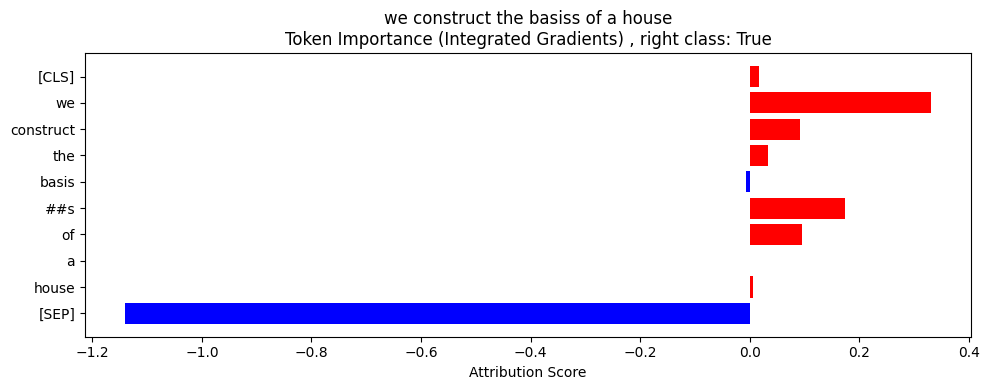

(0.7830544114112854,
 [('[CLS]', 0.016813507303595543),
  ('we', 0.3307263255119324),
  ('construct', 0.09099913388490677),
  ('the', 0.034139446914196014),
  ('basis', -0.006240209564566612),
  ('##s', 0.17358402907848358),
  ('of', 0.09499682486057281),
  ('a', 0.0007806909270584583),
  ('house', 0.005329375620931387),
  ('[SEP]', -1.1401957273483276)])

In [323]:
chunk = "we construct the basiss of a house"
classify_and_explain(chunk, model, tokenizer)

# Now test it for multiple paragraphs

In [324]:
#df_test = pd.read_csv("projects/nace_classification/nace_report_topic_analysis/data/training_data/test_dataset_sentiment/test_data.csv")
df_test = pd.read_csv("projects/nace_classification/nace_report_topic_analysis/results/BERT_models/Relevancy_Classifier/relevancy_judge__2__dataset__2__num_layers_3__train_full_model_True_bert-base-uncased/all_test_df.csv")

In [317]:
path_df = "projects/nace_classification/nace_report_topic_analysis/results/BERT_classification/model_1_1__desc_pages__with_relevancy__dataset__stoxx_600_sentence_len_6__nace_level_1/Siemens Energy AG1.txt/Siemens Energy AG1.txt_classifications.csv"
path_df = "projects/nace_classification/nace_report_topic_analysis/results/BERT_classification/dataset__stoxx_600__desc_page__sentence_len_6__nace_level_1/Siemens Energy AG1.txt/Siemens Energy AG1.txt_classifications.csv"
path_df = "projects/nace_classification/nace_report_topic_analysis/results/BERT_classification/model_1_0__with_relevancy__dataset__reports_subset_from_full_data_3_sentence_len_6__nace_level_1/BWX Technologies, Inc.1.txt/BWX Technologies, Inc.1.txt_classifications.csv"
path_df = "projects/nace_classification/nace_report_topic_analysis/results/BERT_classification/model_1_0__with_relevancy__dataset__reports_subset_from_full_data_3_sentence_len_6__nace_level_1/Allreal Holding AG1.txt/Allreal Holding AG1.txt_classifications.csv"
df = pd.read_csv(path_df, index_col=0)

In [318]:
path_store = "/".join(path_df.split("/")[:-1])
path_store

'projects/nace_classification/nace_report_topic_analysis/results/BERT_classification/model_1_0__with_relevancy__dataset__reports_subset_from_full_data_3_sentence_len_6__nace_level_1/Allreal Holding AG1.txt'

In [319]:
df_true = df[df["Relevancy_over_0_5"]]
df_true

,F,P,L,K,I,A,D,G,E,NO_CLASS,B,J,H,Q,M,N,C,Sentences,Relevancy_sig,Relevancy_over_0_5
39,2.111515,-2.937336,8.783928,1.164535,-0.941408,-1.037390,-1.429641,-0.067416,-0.882207,-3.483190,-0.221487,-2.037065,-1.769291,-2.684775,-1.956614,-0.363671,-1.923009,the projects amp development division provides...,0.655440,True
89,1.241932,-0.946810,-4.438236,0.259961,0.318577,-3.272902,-3.609311,-1.002678,-1.824805,9.334316,-3.595888,-3.124276,-0.420681,0.513394,-0.051385,0.263460,-0.233911,the focus is on a high level of customer benef...,0.688589,True
96,1.026082,-0.907321,-4.435998,0.413046,0.252161,-3.264138,-3.604244,-0.963550,-1.880162,9.365194,-3.514931,-3.048625,-0.306078,0.552164,-0.147386,0.273959,-0.345346,allreal strives to achieve sustainabilityorien...,0.748109,True
228,8.251976,-2.414534,2.019570,-1.414623,-0.904512,-3.192301,0.748791,-1.943900,-0.687636,-0.752660,-0.853968,-2.962066,-1.054636,-2.085646,-0.640970,-1.384275,0.320982,with its selective participation in the thirdp...,0.943007,True
257,1.788564,-2.979213,8.801582,1.249912,-0.981685,-0.881849,-1.456157,-0.036871,-0.828937,-3.573865,-0.069637,-2.075350,-1.770758,-2.644833,-2.022988,-0.351949,-1.964037,investments in residential and commercial prop...,0.859219,True
307,1.152918,-0.457728,-4.133338,-0.333117,-0.561195,-3.347654,-2.803052,-1.461929,-2.213881,8.266308,-3.699918,-2.910369,-0.512608,1.457691,1.041669,-0.012961,-0.116123,we also provide the board of directors or its ...,0.805046,True
315,1.749363,-3.013138,8.793406,1.223898,-0.995087,-0.873184,-1.453512,-0.036859,-0.764125,-3.579072,0.021011,-2.134656,-1.799775,-2.657670,-2.046827,-0.390861,-1.953985,the real estate division secures stable added ...,0.894233,True
330,7.883764,-2.395284,2.653644,-1.002397,-0.408893,-3.129184,0.438258,-1.812868,-0.903313,-0.695406,-0.556210,-2.938623,-1.010360,-2.193810,-0.966656,-1.222245,-0.277779,block with solar modules on the roof and on th...,0.868050,True
362,1.855186,-3.016789,8.809901,1.180440,-1.004401,-0.947169,-1.445918,-0.016918,-0.780556,-3.578031,-0.014248,-2.138592,-1.788931,-2.677385,-2.025952,-0.381116,-1.948132,allreal group is a real estate company which o...,0.873537,True
454,1.645685,-3.005471,8.760733,1.261618,-0.991220,-0.772559,-1.517720,0.032346,-0.770535,-3.598347,-0.038068,-2.111081,-1.789255,-2.636209,-2.069961,-0.340158,-1.939899,commercial real estate held on a continuous ba...,0.873356,True


In [328]:
df_test

,Unnamed: 0,label,prediction,text,probabilities,positive,notes
0,0,False,False,the european regulation eu no on otc derivativ...,0.206084,True,NaN
1,1,False,False,renata brings strong commercial and digital ex...,0.701831,True,NaN
2,2,False,False,acquiring land in areas of high demand and in ...,0.691264,True,NaN
3,3,True,True,firmenich is the most vertically integrated pl...,0.749082,True,NaN
4,4,False,False,arevised group treasury policy wasconsidered b...,0.198166,True,NaN
...,...,...,...,...,...,...,...
287,287,False,False,the following diagram describes the qualitativ...,0.211267,True,NaN
288,288,False,False,in september australia passed a law which aims...,0.207756,True,NaN
289,289,False,False,growthrate in perpetuity discount rate,0.199434,True,NaN
290,290,False,False,number of appointed privacy officers under the...,0.202658,True,NaN


firmenich is the most vertically integrated player in the industry with the best access to raw materials and natural ingredients.


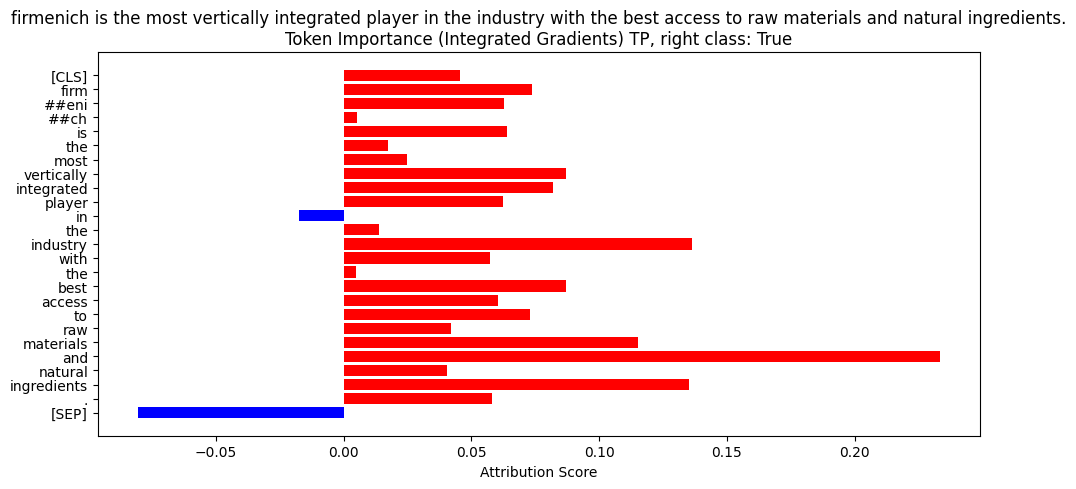

we have the exclusive right to manufacture and sell the beverages of the cocacola company in our markets.


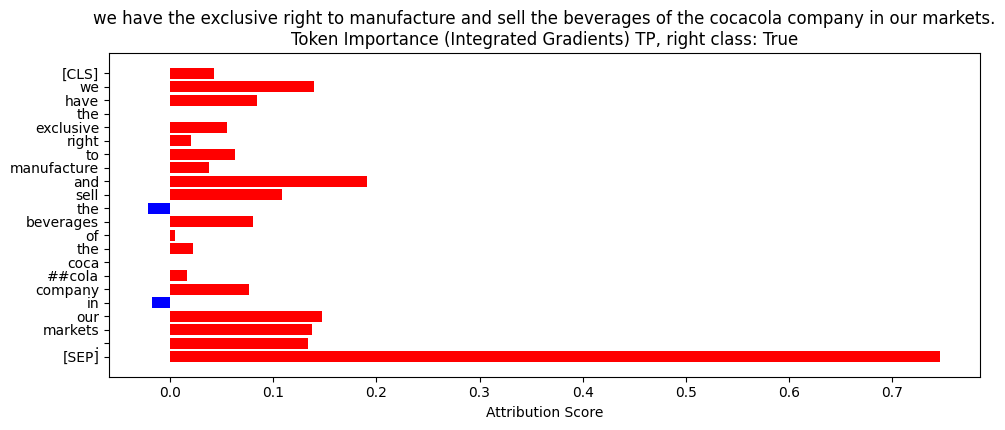

the product portfolio also includes boilers for power generation flue gas cleaning systems various nonwoven technologies and panelboard mdf production systems.


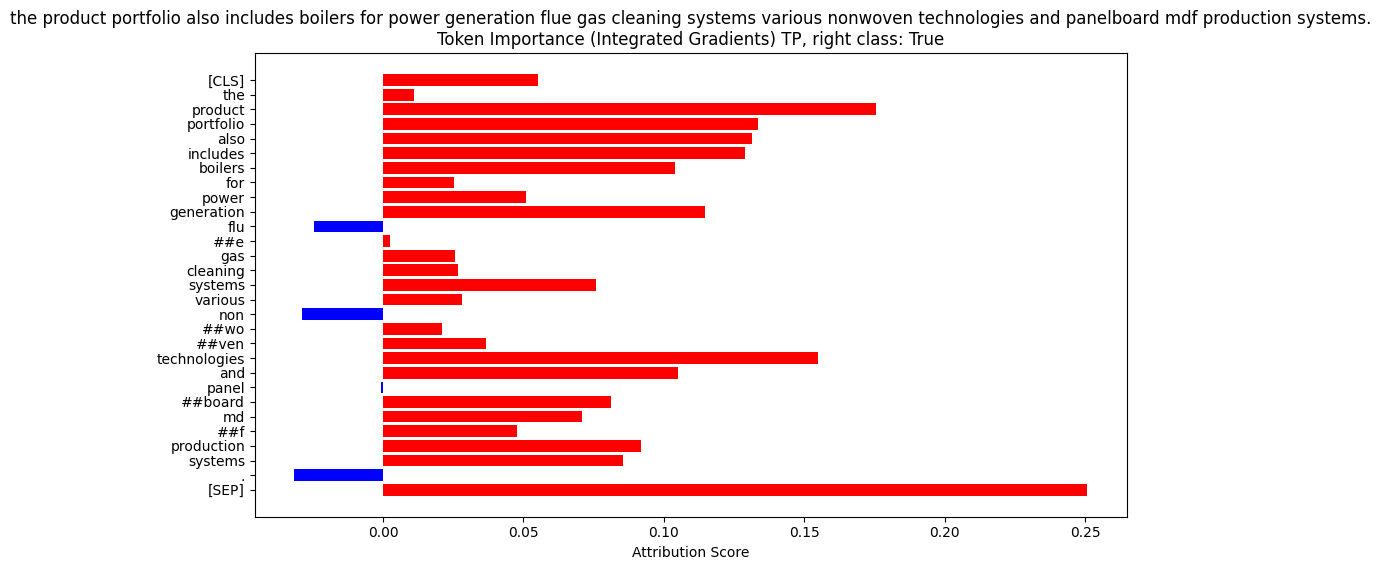

a.s.r. works to help customers gain insight into their financial situation and make conscious financial decisions.


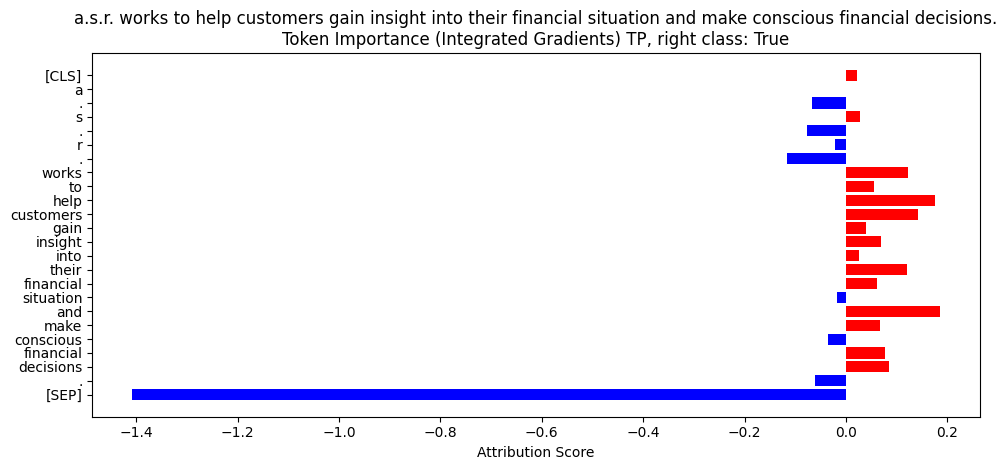

we operate across four market segments delivering value and great customer experiences.


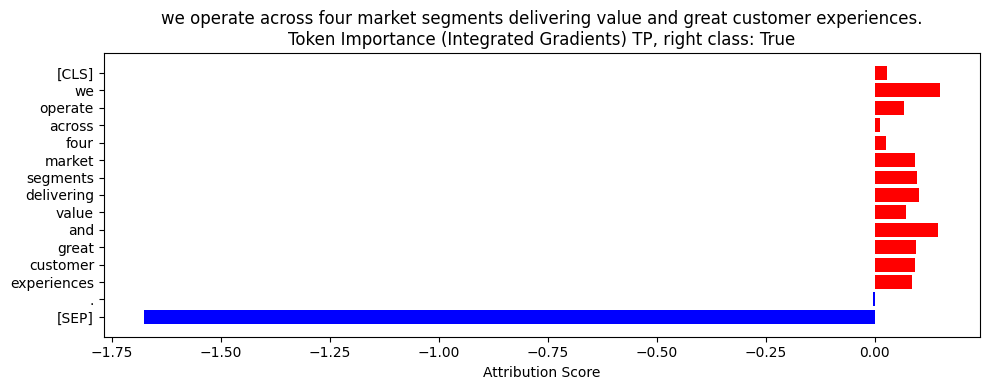

we finance develop build maintain and operate the increasingly complex and critical infrastructure that supports national economies and deliver projects at the heart of local communities.


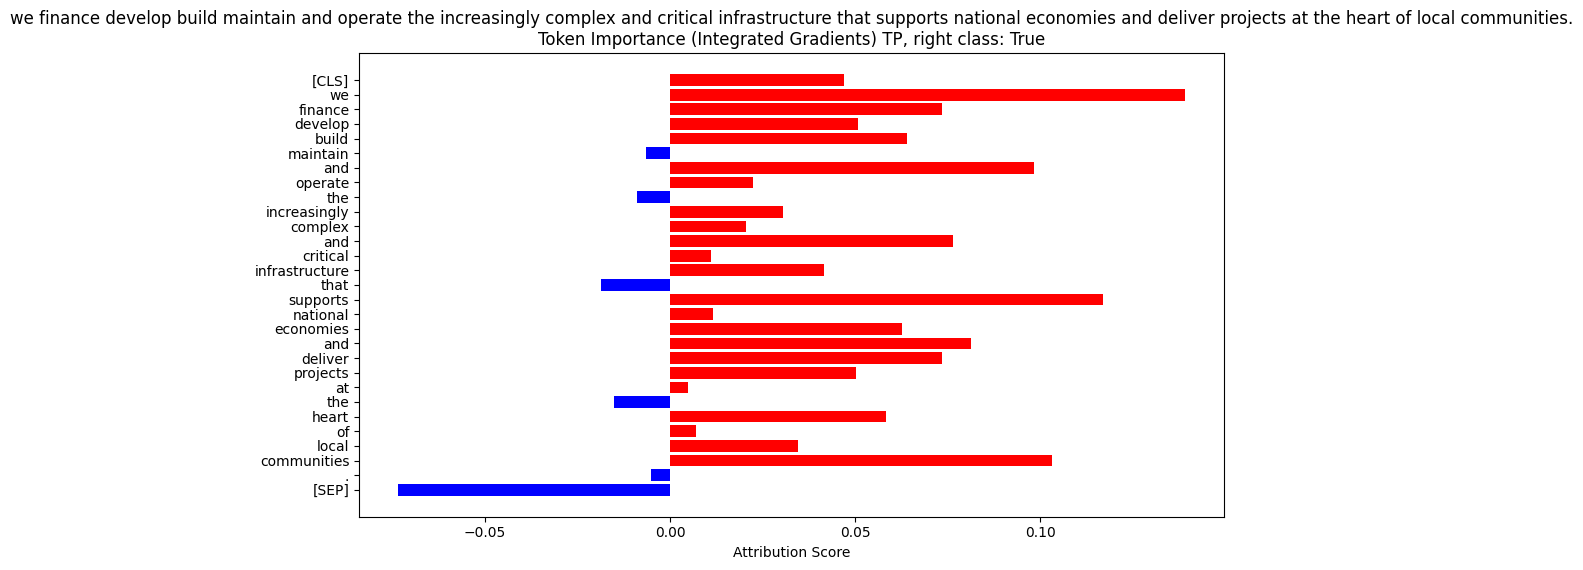

andritz pulp amp paper provides sustainable technology automation and service solutions for the production of all types of pulp paper board and tissue.


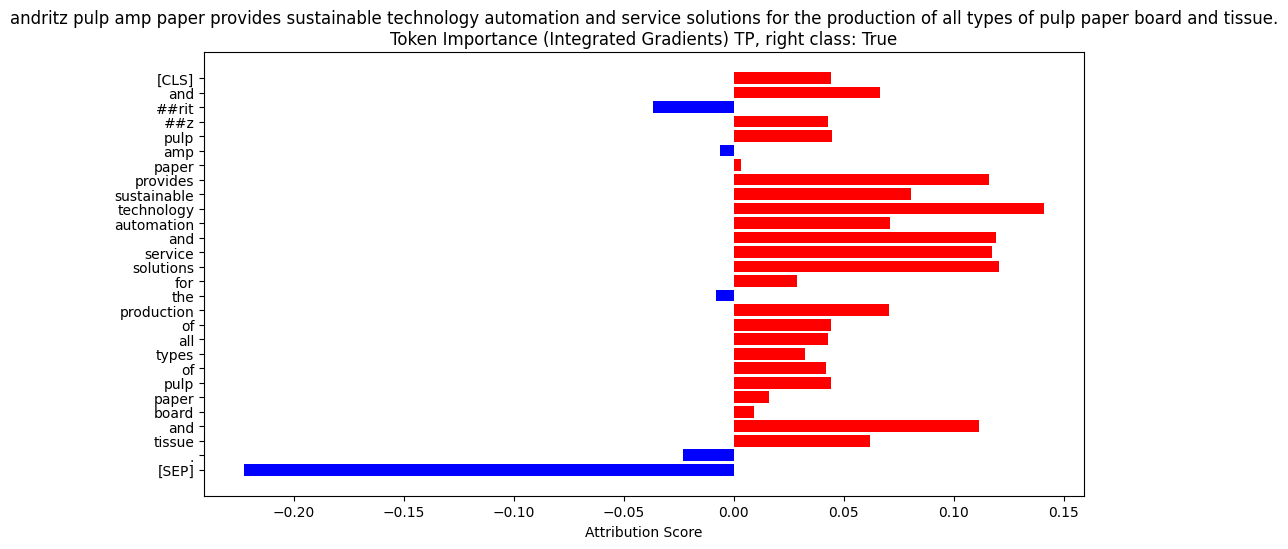

clean gas and green electricity from our sludge anaerobic digestion plants


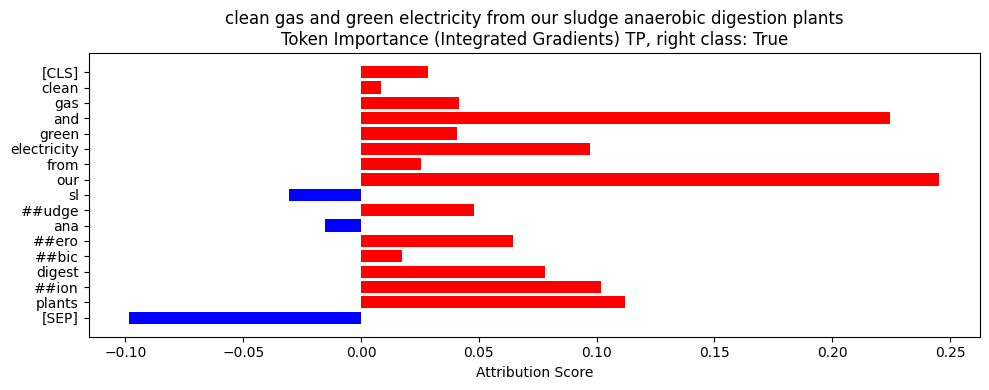

highend solu tions for industrial environments from rampd to production settings. xraysystem


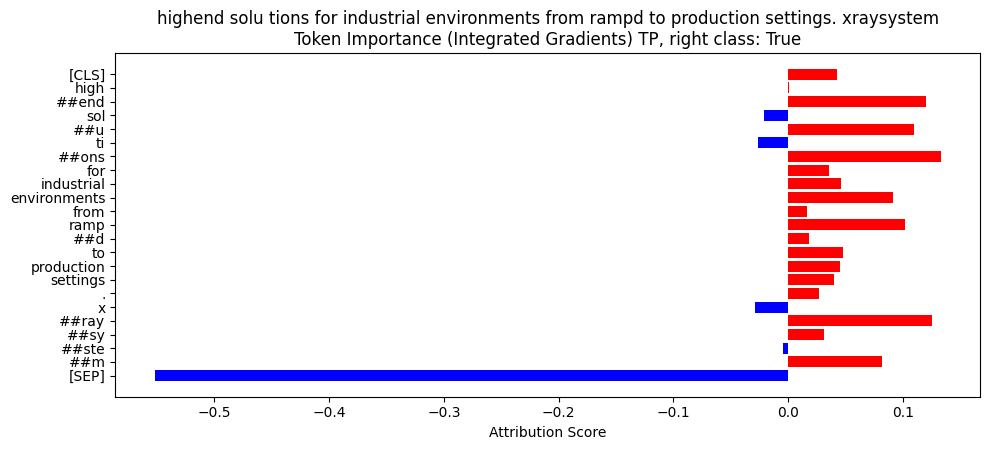

we have a unique setup with different disciplines under one roof.


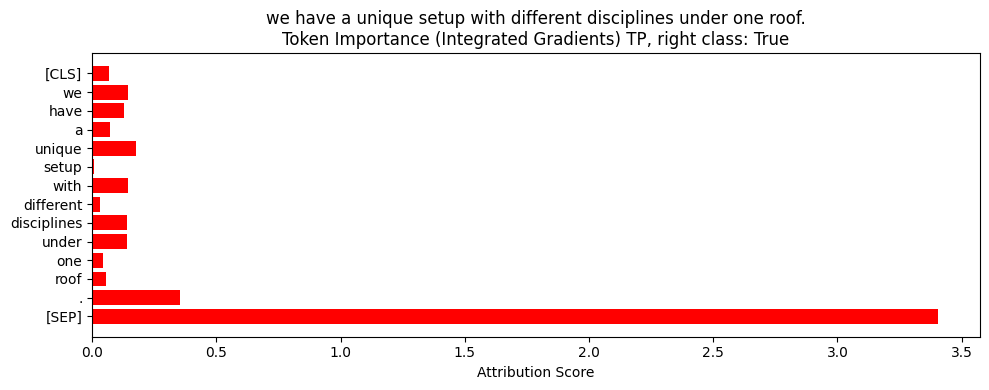

In [330]:
for sentence in df_test[(df_test["positive"]) & (df_test["label"])].head(10)["text"]: 
    print(sentence)
    if len(sentence.split(" ")) > 4:
        classify_and_explain(sentence, model, tokenizer, "cpu", os.path.join(path_store, f"sentence_false_{i}"), "TP")

the european regulation eu no on otc derivatives central counterparties and trade repositories emir introduced a number of risk mitigation techniques for noncentrally cleared otc derivatives in and the reporting of otc and exchange traded derivatives in .


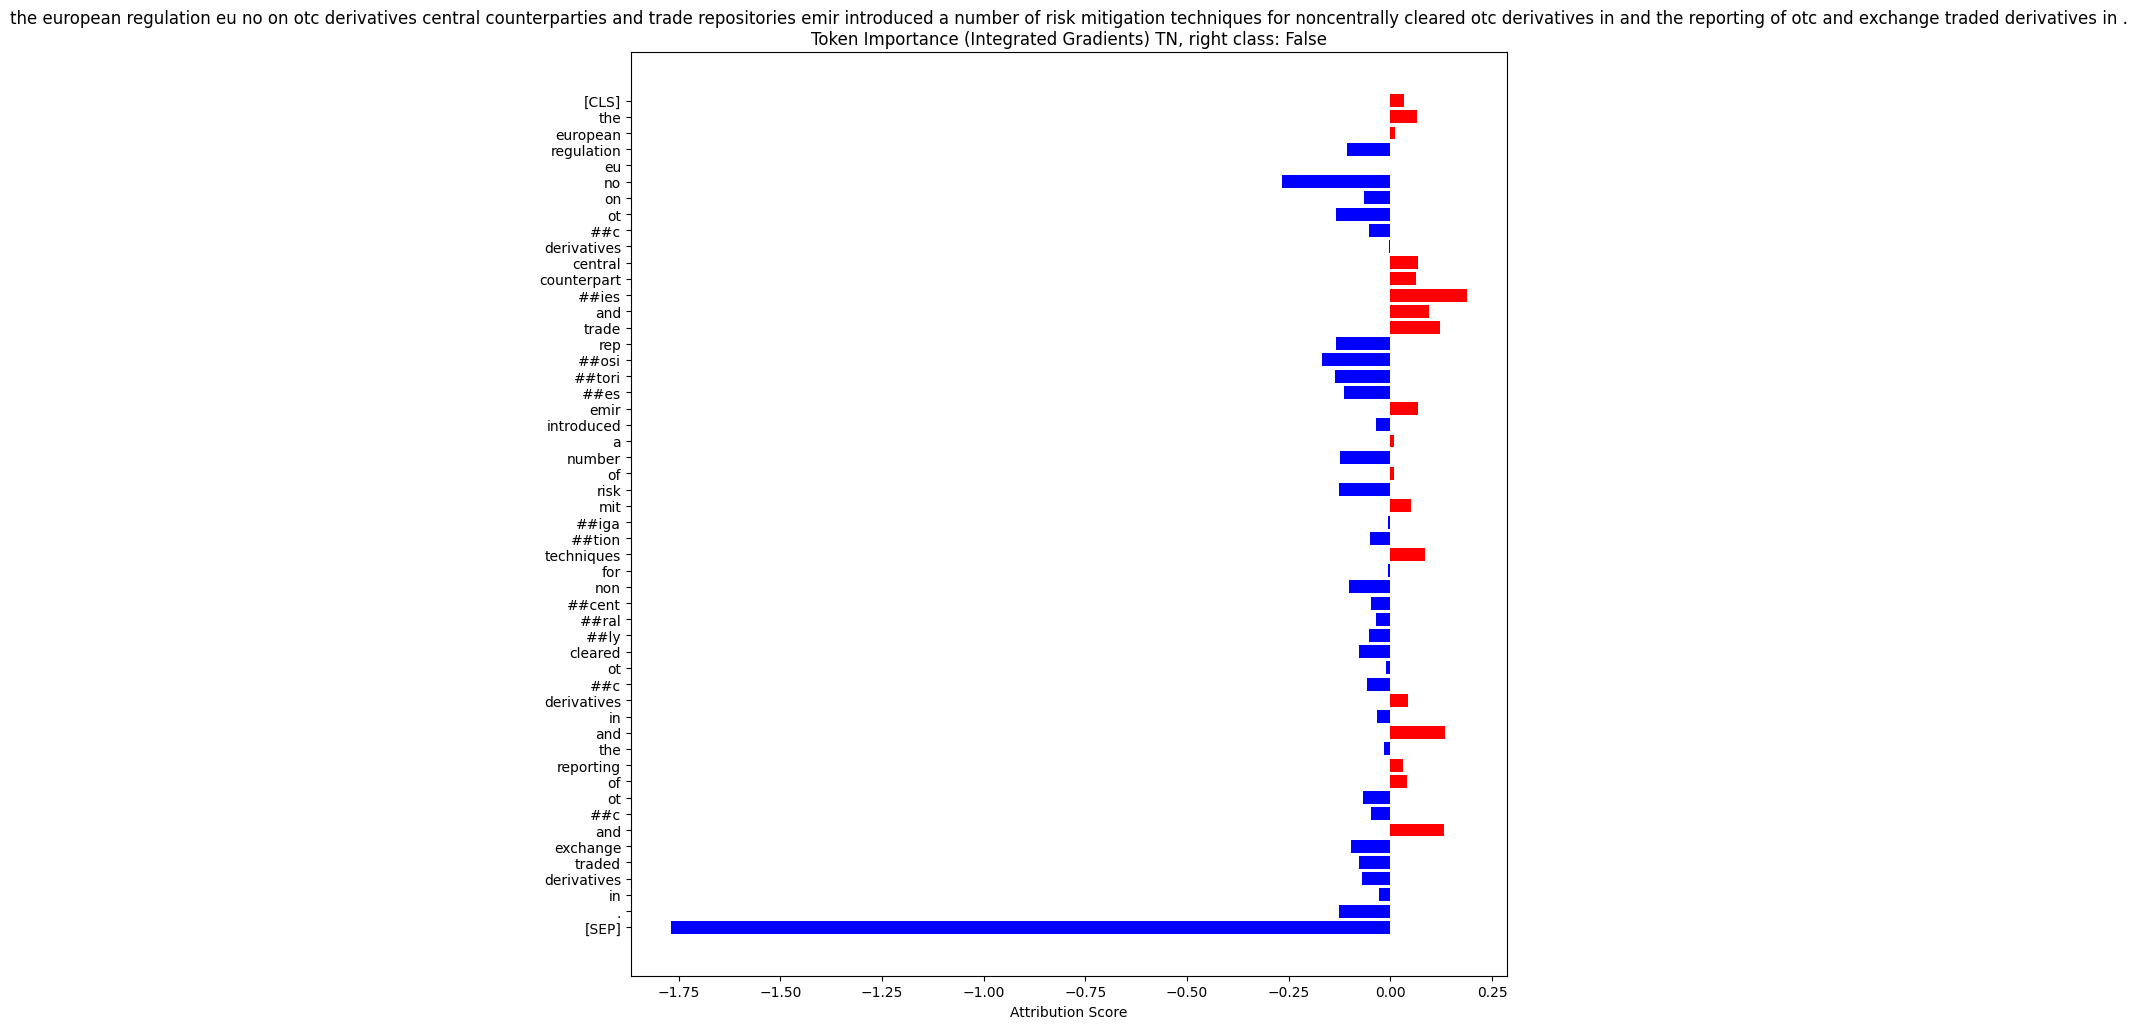

renata brings strong commercial and digital experience to the board.


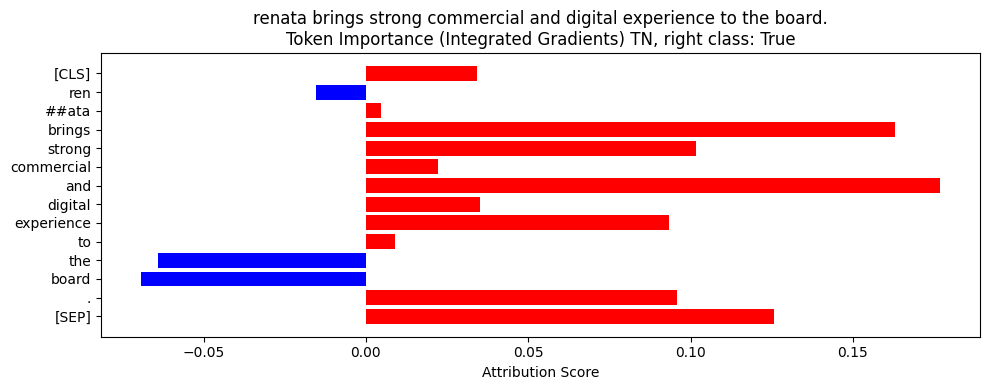

acquiring land in areas of high demand and in attractive locations in accordance with the groups financial and nonfinancial acquisition criteria is one of the key factors to the success of bellway.


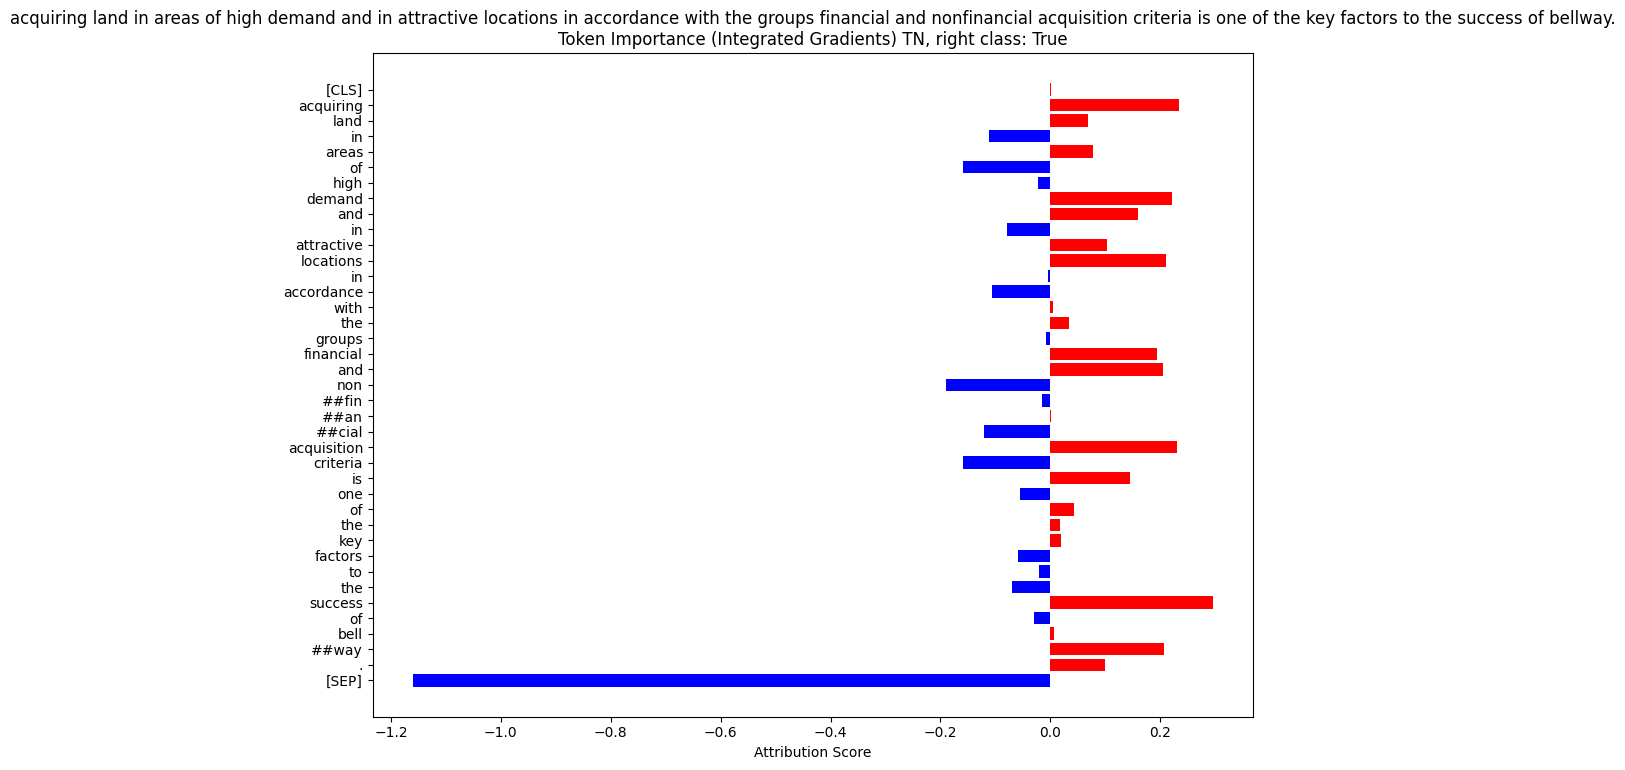

arevised group treasury policy wasconsidered by the board and audit committee. the board and audit committee considered the groups di


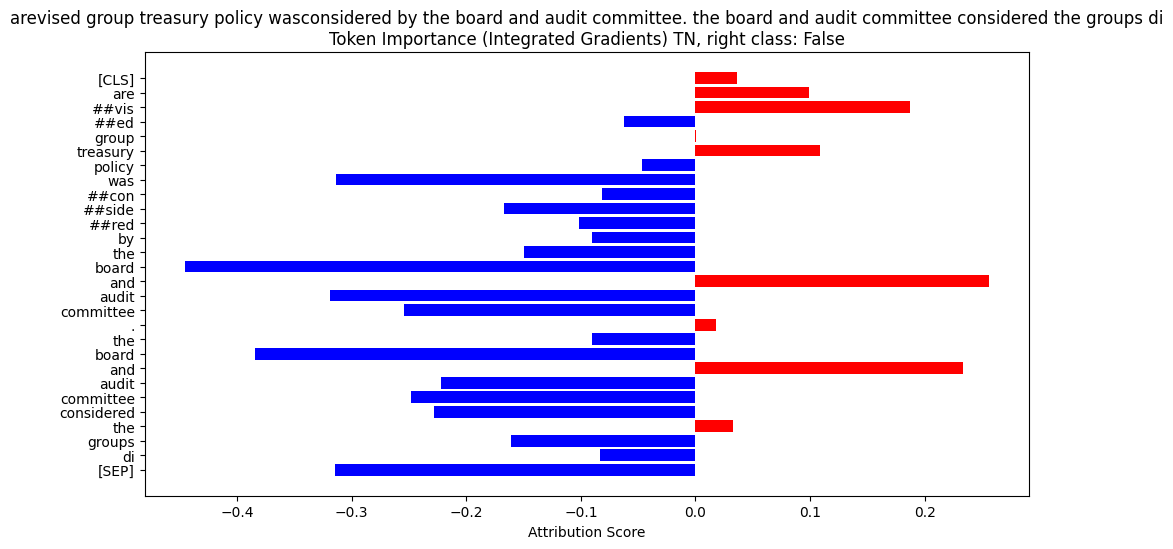

profit before profit transfers and taxes


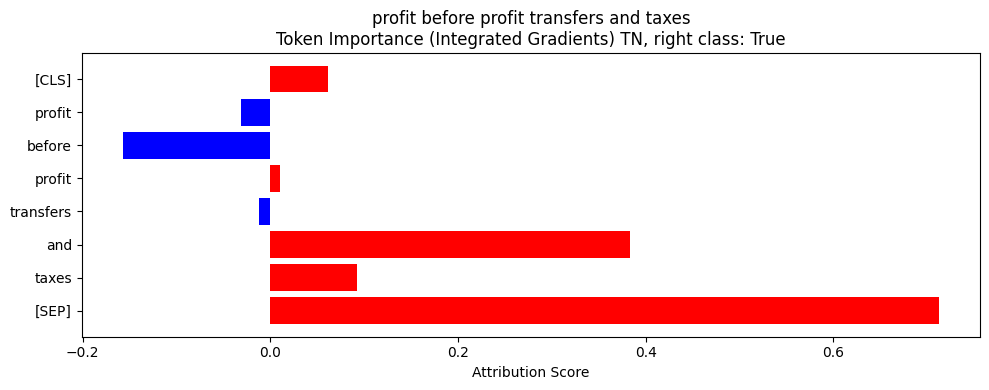

dongtan engineering manufacturing mediumhigh high


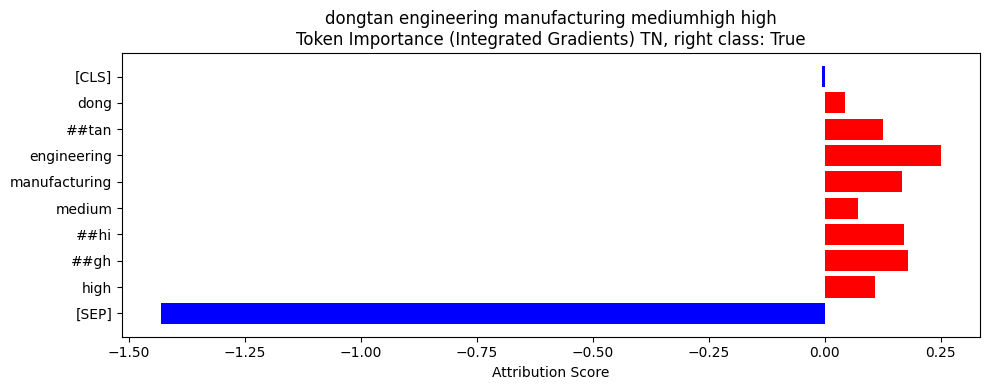

total trade accounts receivable
order backlog .bn order backlog .bn order backlog .bn


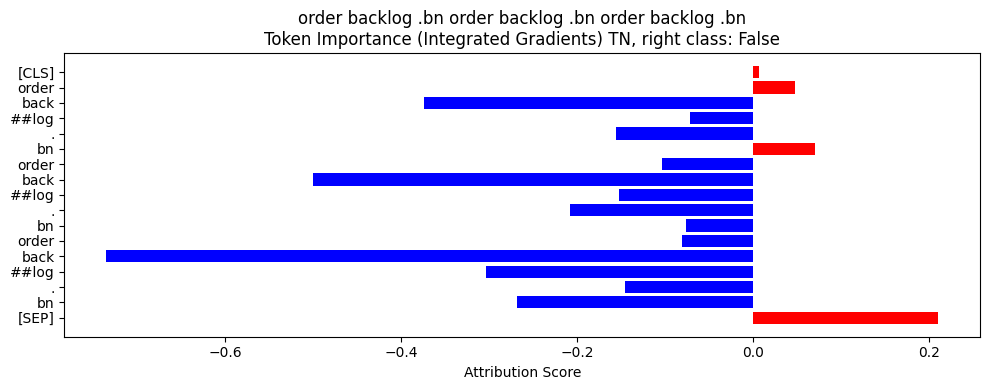

it carries markup rate ranging from to to per annum.


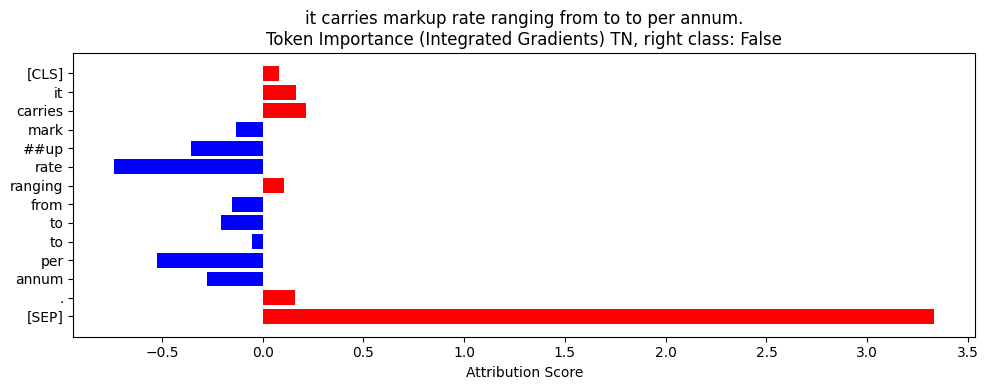

bkw provides information on the annual results in the form of an annual report in electronic form. the annual report can be downloaded at www.bkw.channualreport.


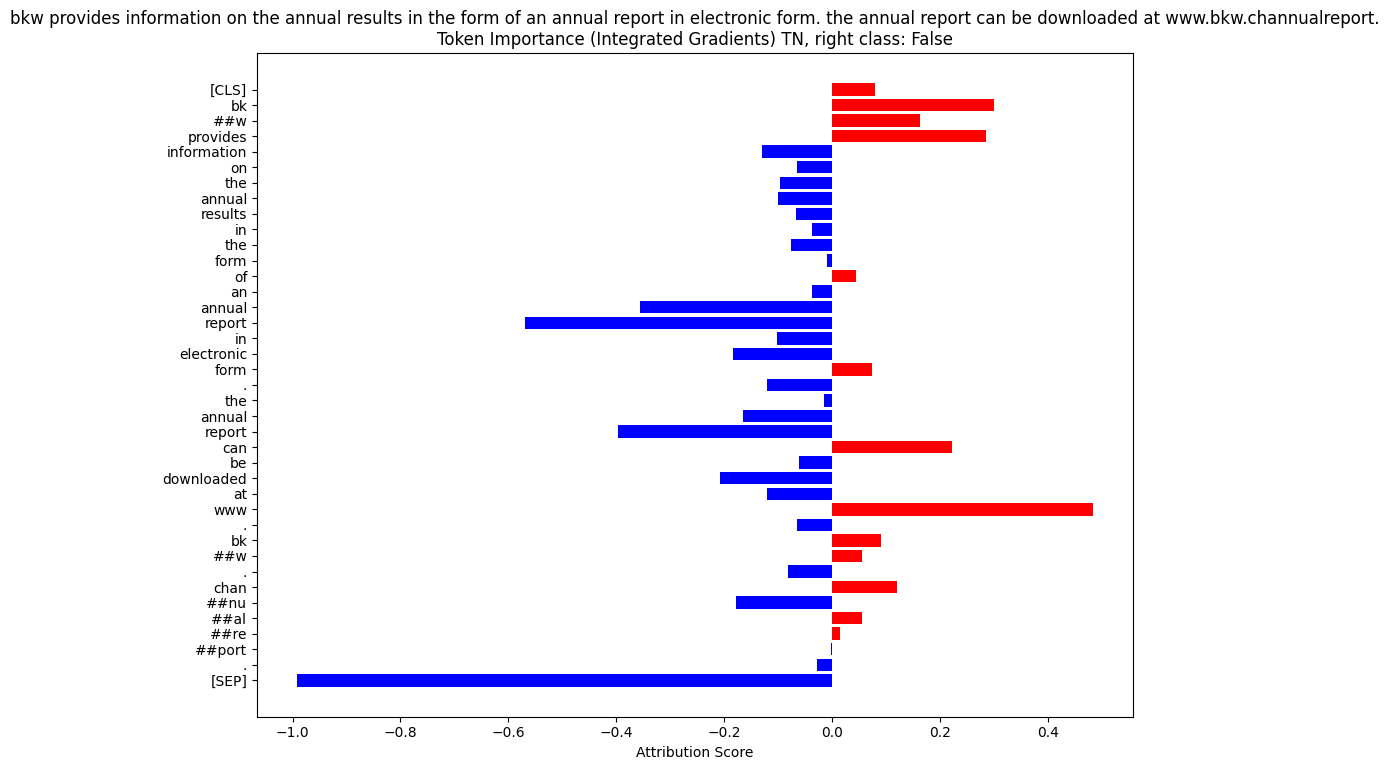

In [331]:
for sentence in df_test[(df_test["positive"]) & (~df_test["label"])].head(10)["text"]: 
    print(sentence)
    if len(sentence.split(" ")) > 4:
        classify_and_explain(sentence, model, tokenizer, "cpu", os.path.join(path_store, f"sentence_false_{i}"), "TN")

pioneer and scale regenerative agriculture leading the way for regenerative dairy farming models key ingredients we source directly will come from farms that have begun to transition to regag by


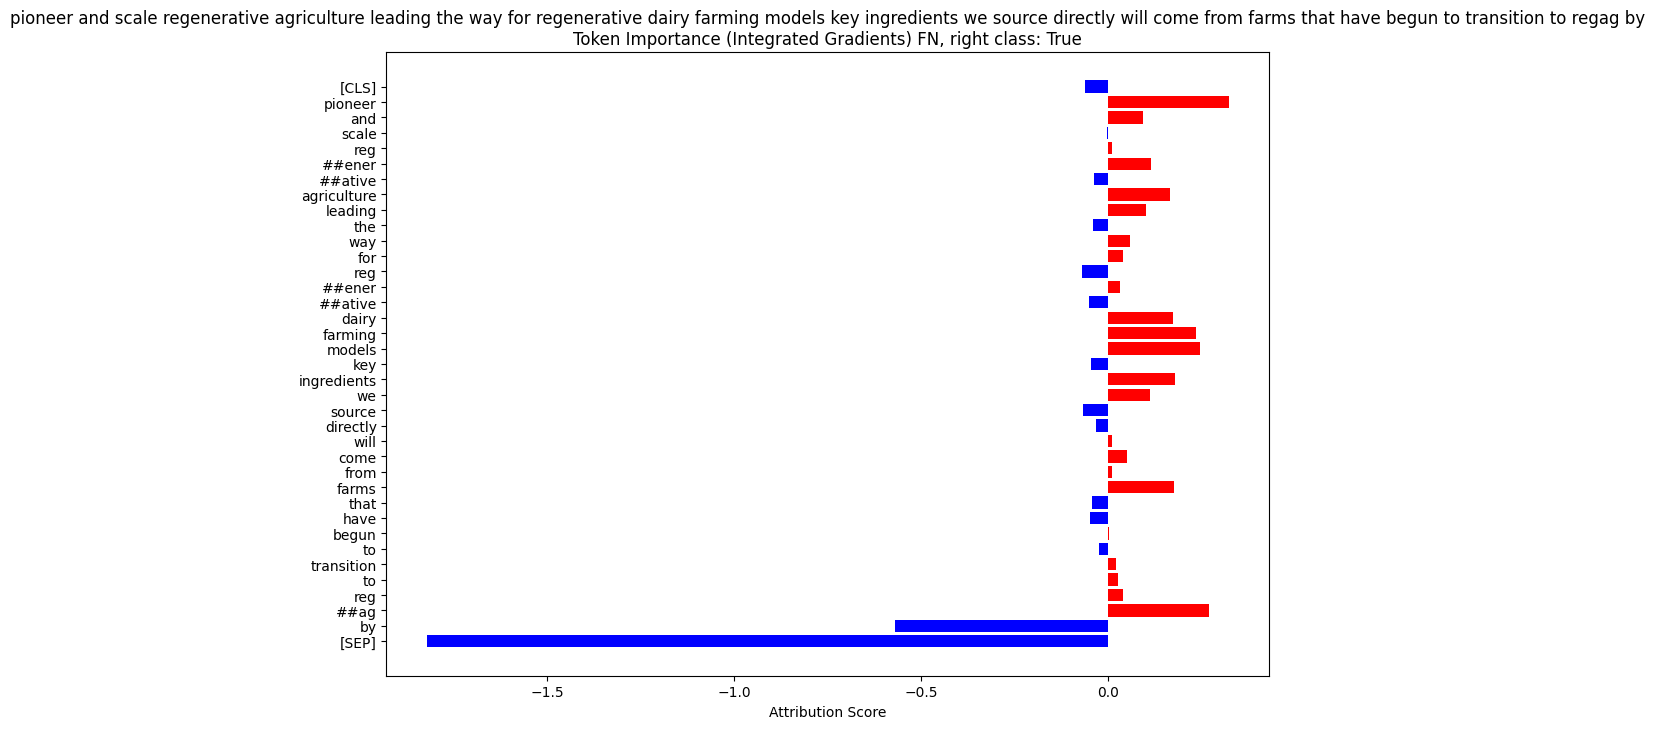

sustainability issues topics occupational health and safety strategic partnerships attracting and retaining the right skills non discrimination. biodiversity mining waste slag the circular economy and resource utilization energy climate water the emission of air pollutants relocation of local residents land restoration. earnings market presence capital markets socioeconomic effects anticorruption and fair competition sustainable business growth stake holder relationships supplier evalua tions relocation of local residents land restoration the rights of indigenous peoples. investing in and promoting the development of new products. contribute to longterm


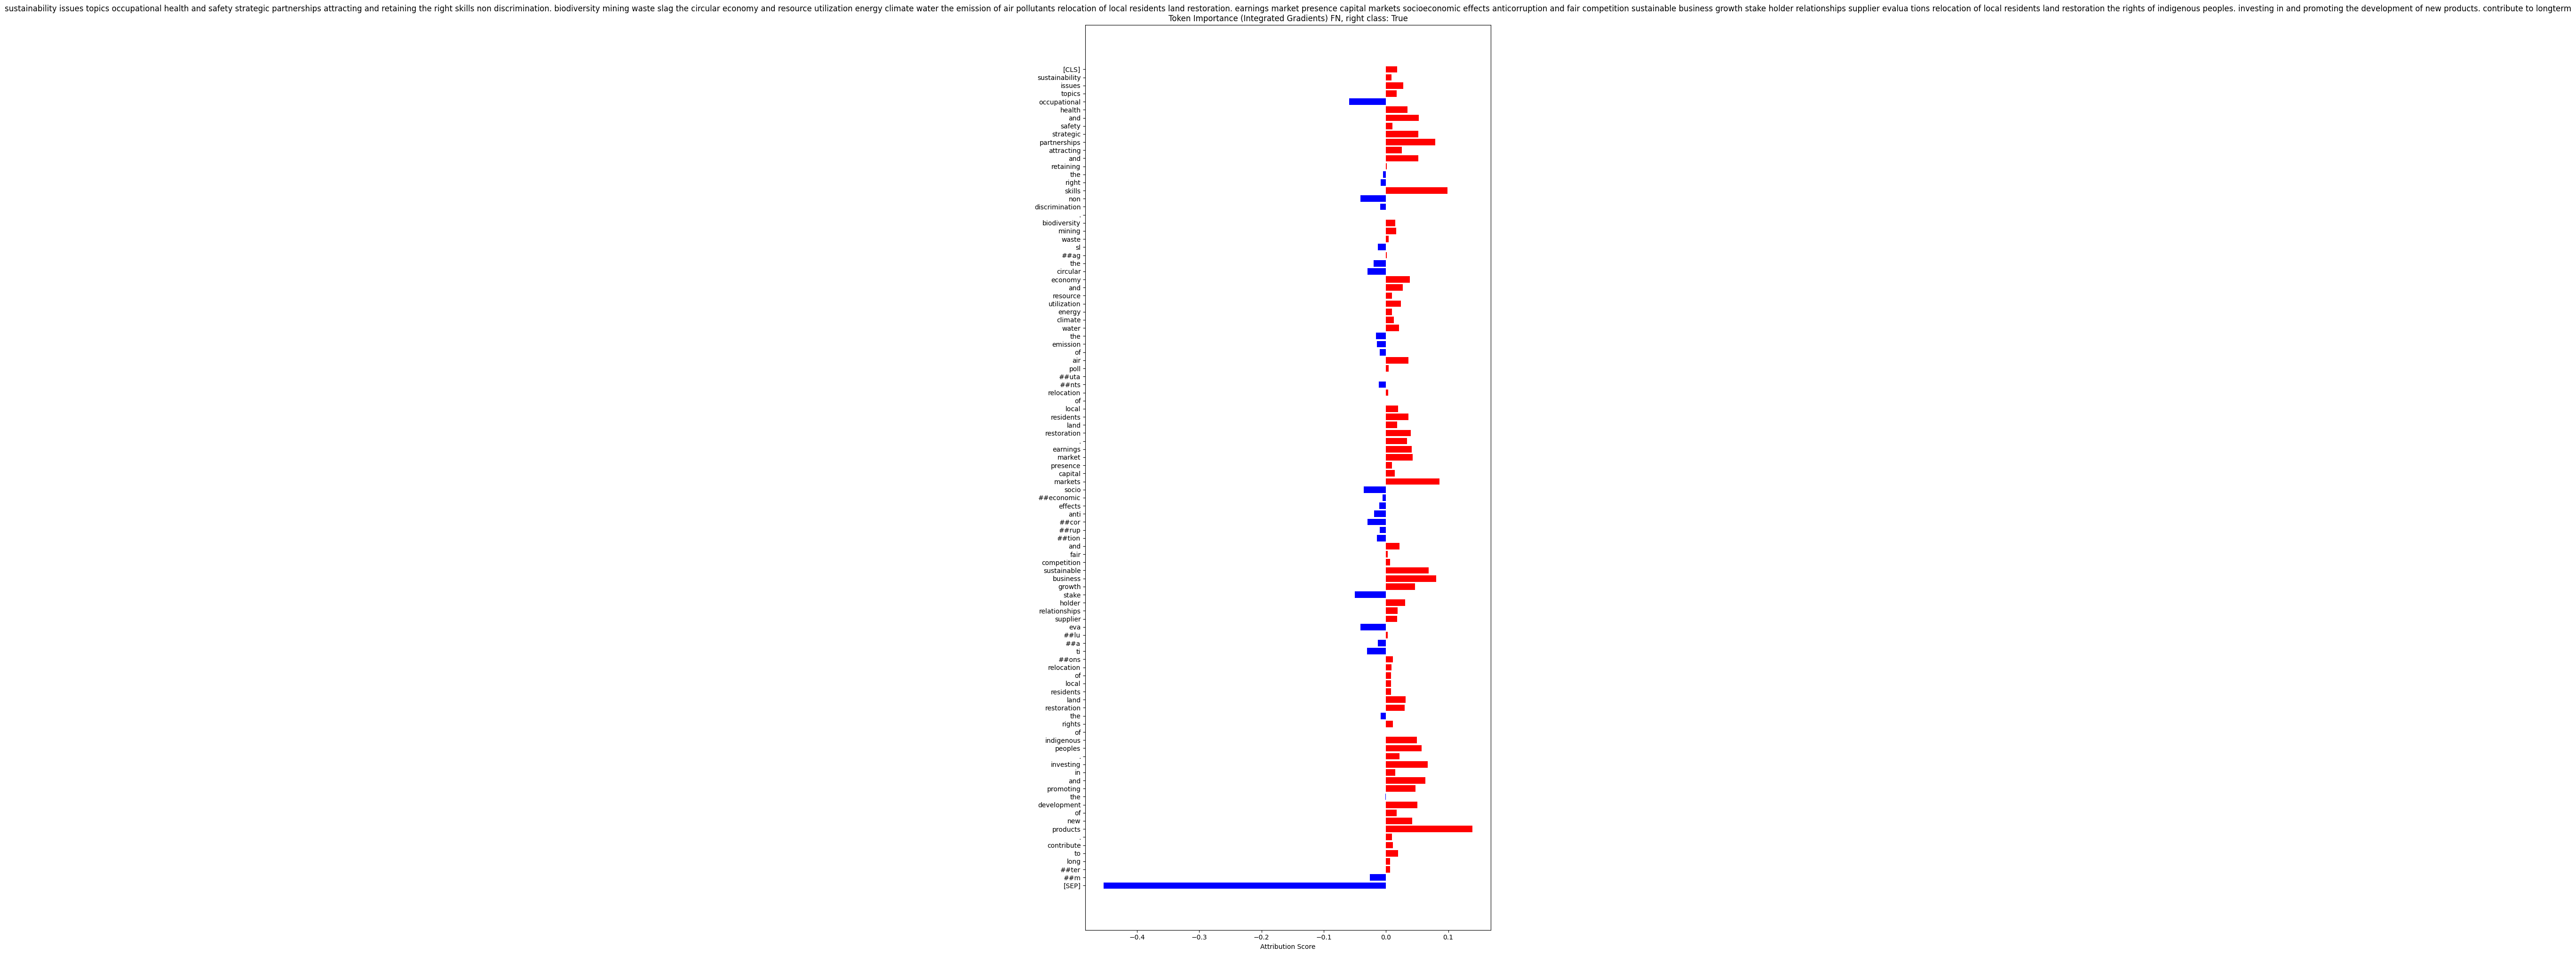

following the reference principles set up by the code of ethics diasorin actively supports the community in which it operates through a series of corporate projects.


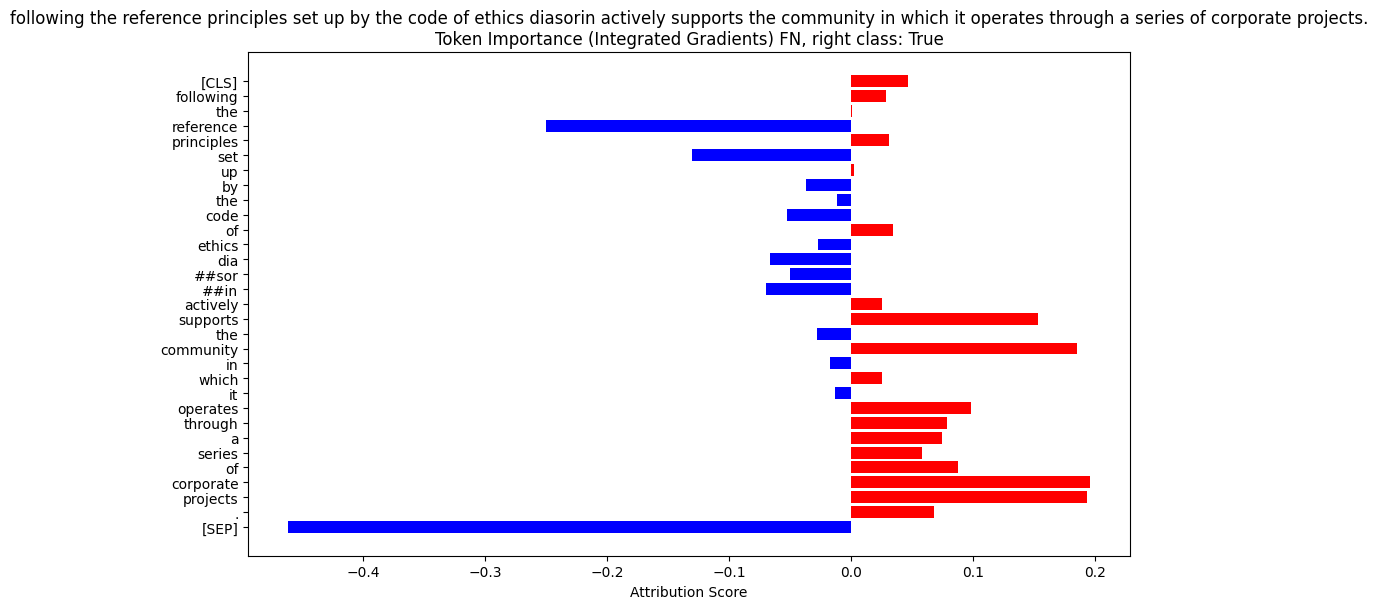

these solutions represent the groups most valuable tools for pursuing its strategy of innovation and sustainable growth. the archimedes asse


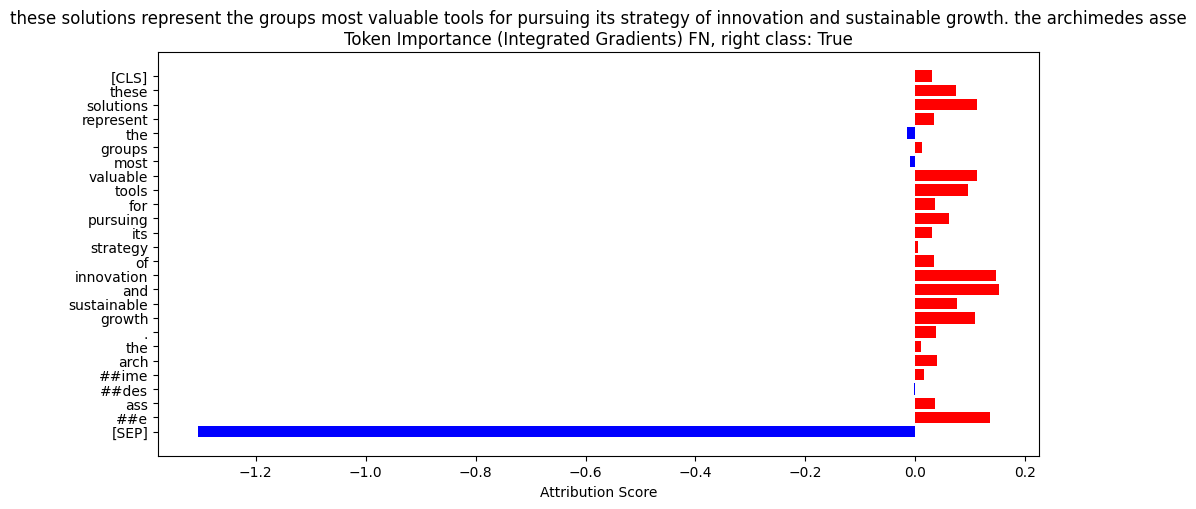

we are determined to play a leading role in addressing the impact of climate change through mitigating our own impact and that of our supply chain and adapting to the challenges that climate change may bring in the future.


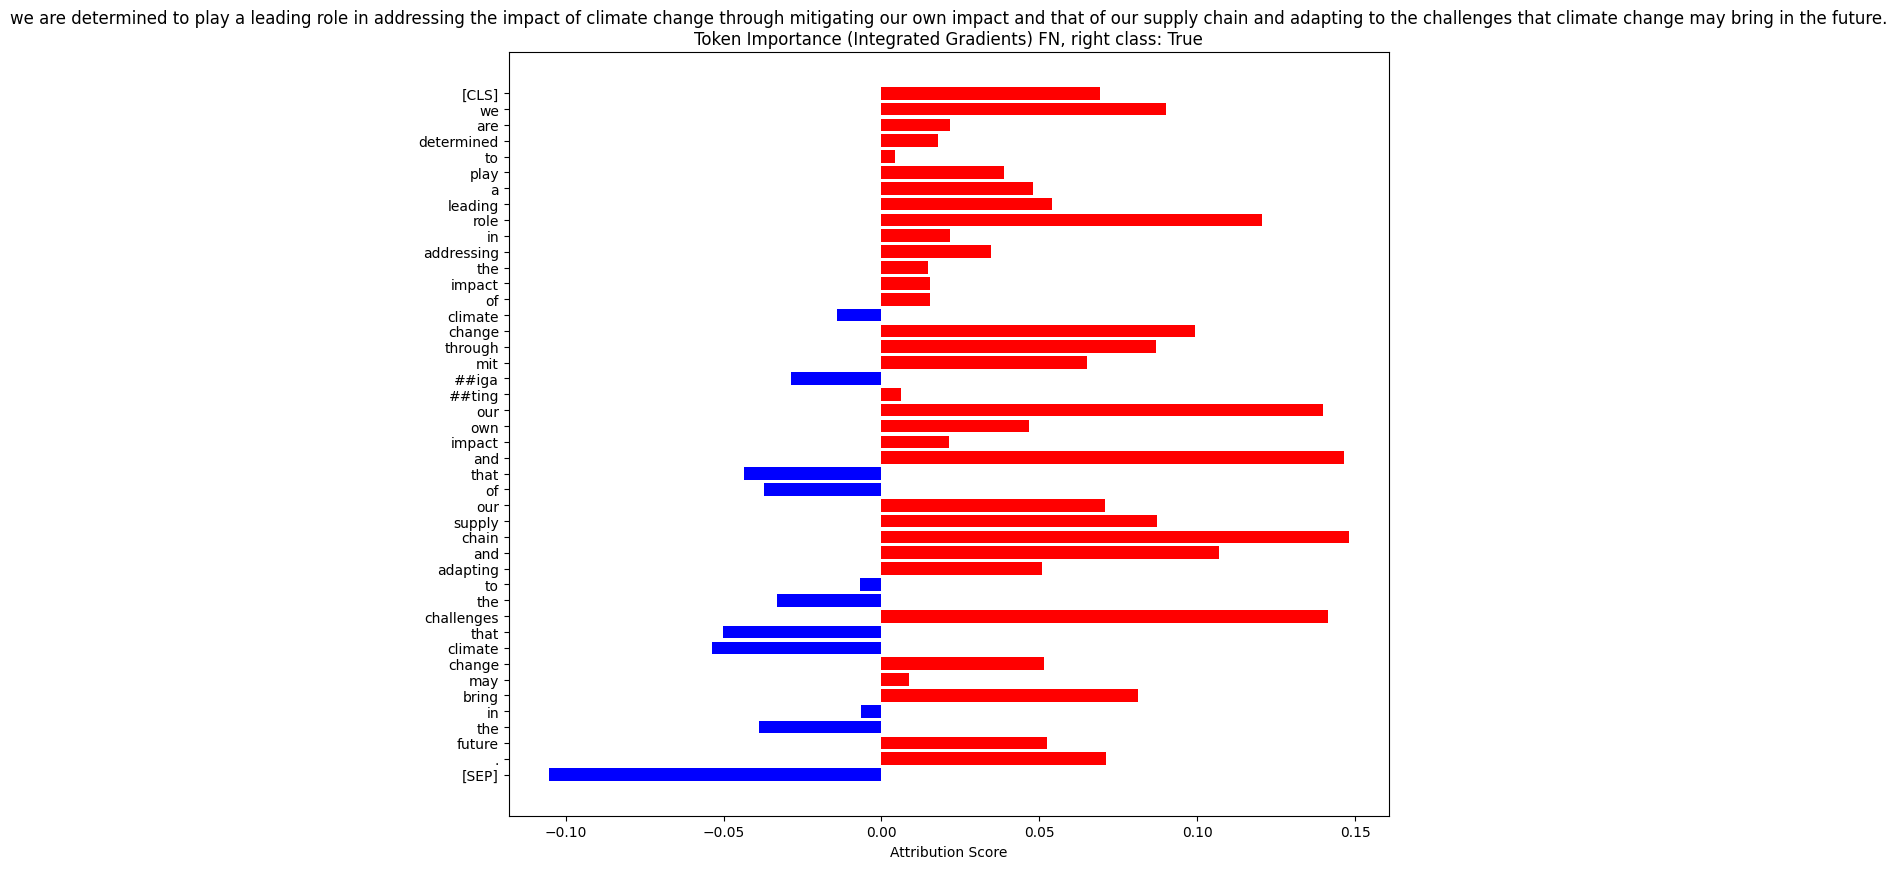

our culture favours taking action today wherever we can make a positive difference instead of leaning on future promises based on imprecise assumptions.


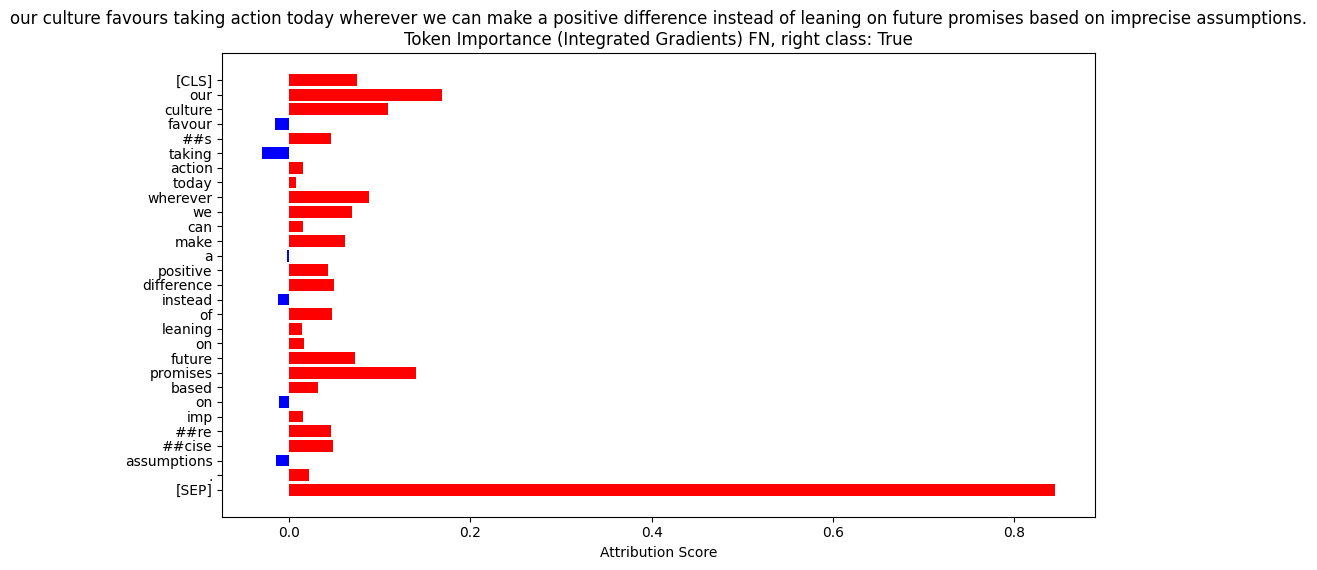

we believe the audit evidence we have obtained is sufficient and appropriate to provide a basis for our opinion.


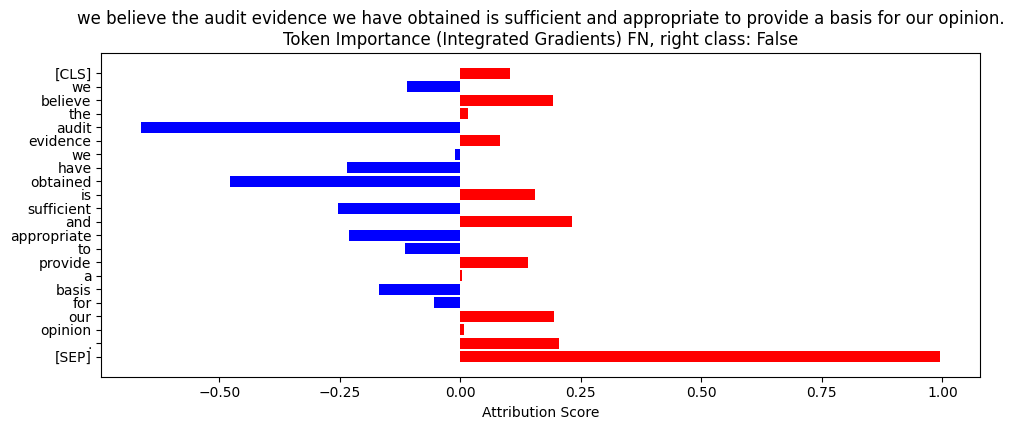

in the global race for innovation the all solid battery is recognized as one of the most promising future paths.


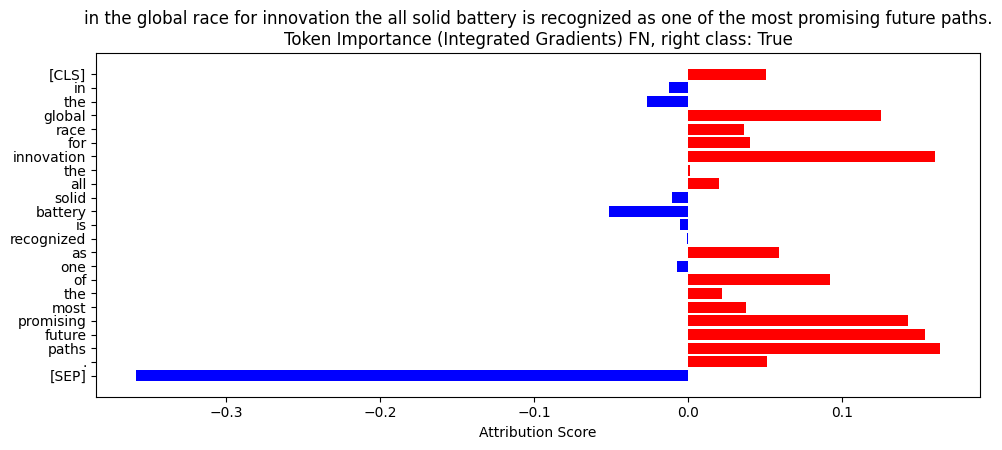

in line with these reference targets diasorin supports the development growth and wellbeing of the local communities in which it operates.


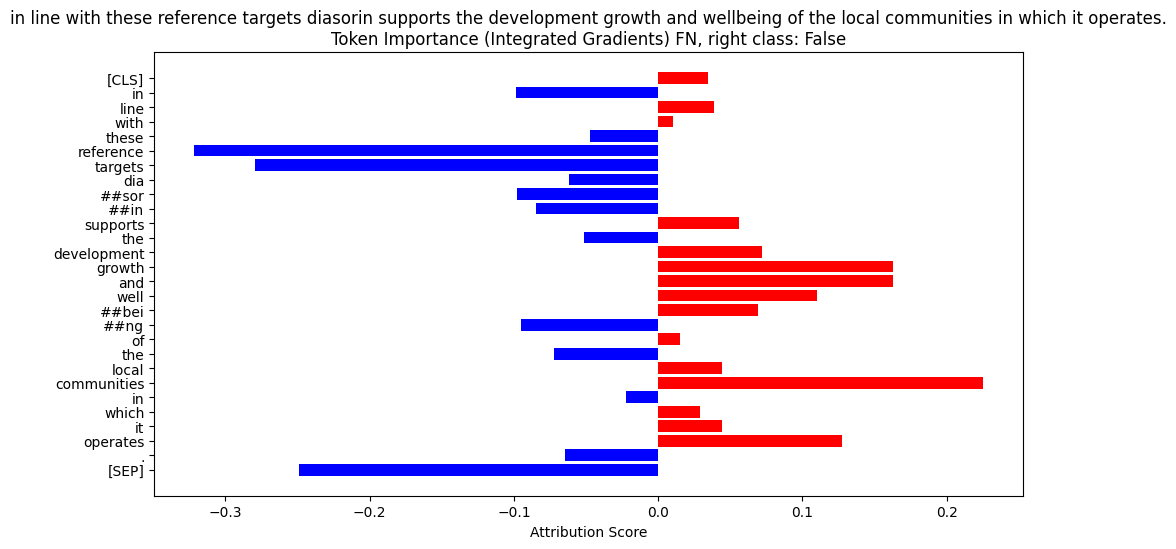

the creditors creditworthiness the ltv and the quality of collateral is an integral part of our risk management when originating loans and when monitoring and steering our credit risks.


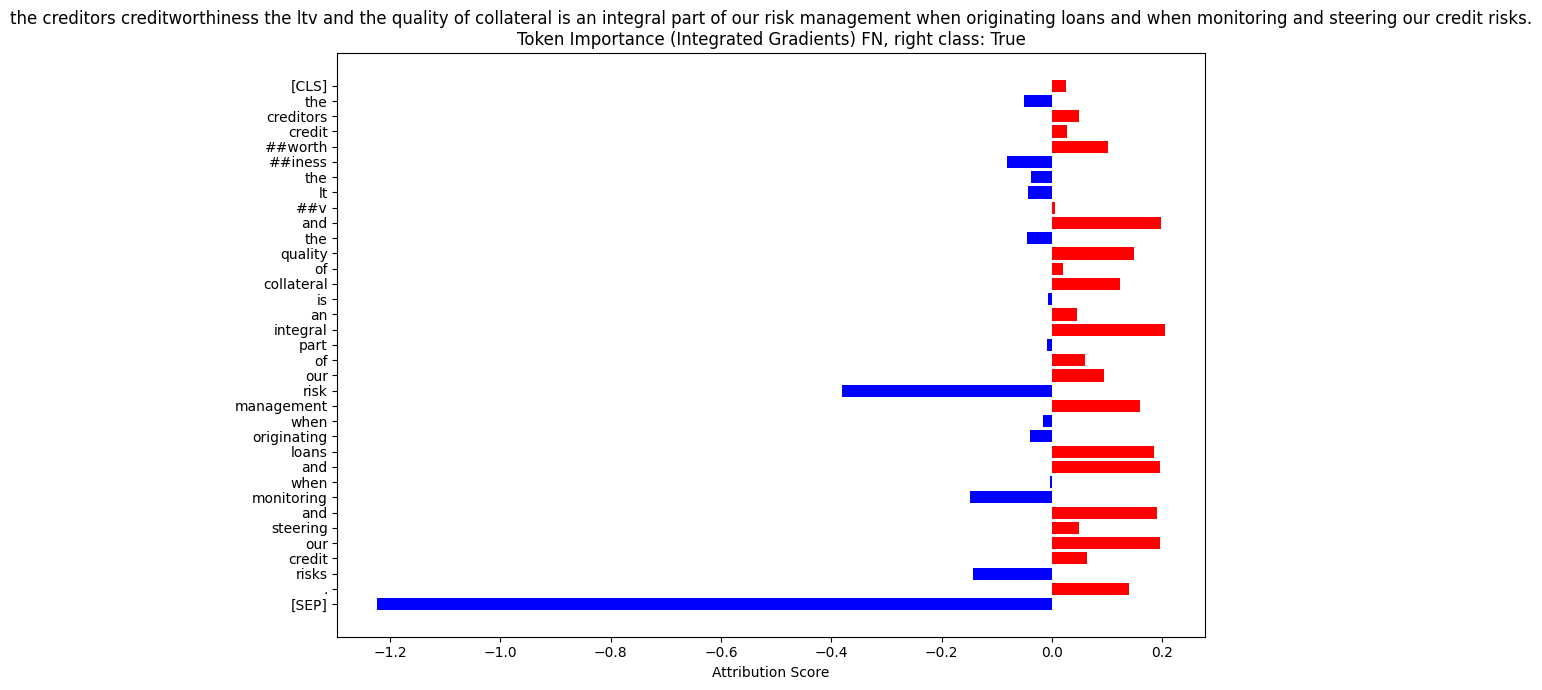

In [332]:
for sentence in df_test[(~df_test["positive"]) & (~df_test["label"])].head(10)["text"]: 
    print(sentence)
    if len(sentence.split(" ")) > 4:
        classify_and_explain(sentence, model, tokenizer, "cpu", os.path.join(path_store, f"sentence_false_{i}"), "FN")

scout betreibt den führenden digitalen marktplatz immoscout.


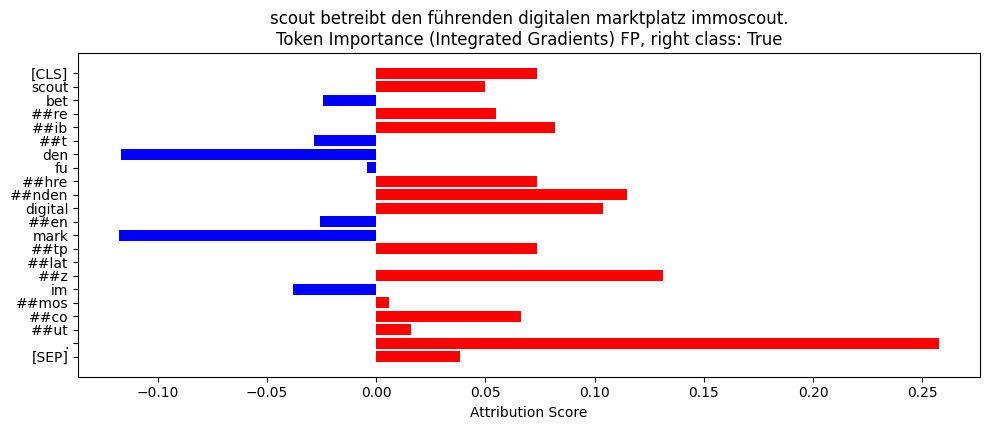

business intelligence analyst janeth fabian chavez at quellaveco copper mine in peru consults the work execution platform app on her mobile phone.


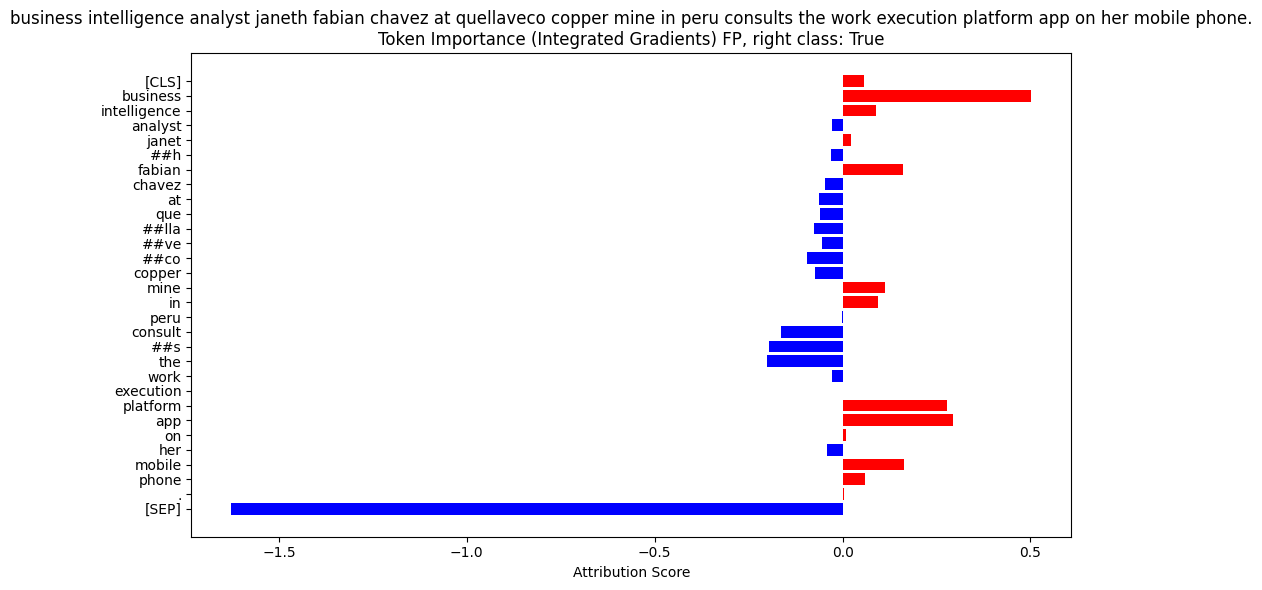

the most important operating and financial targets are defined as follows


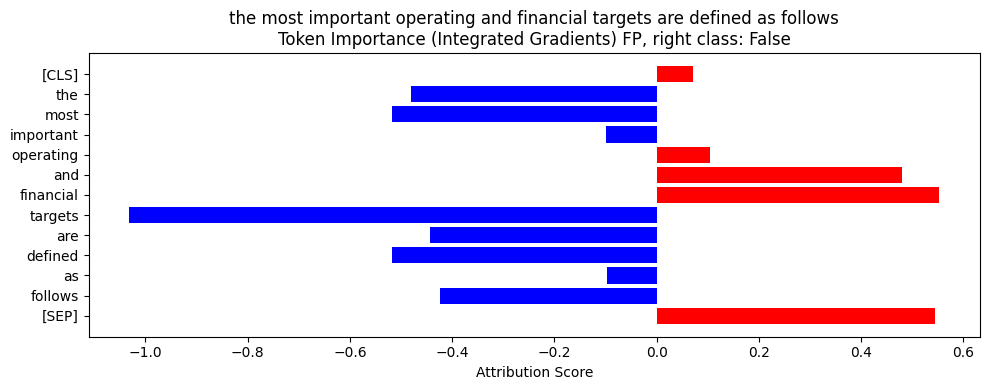

mineral resources include known and indicated resources.


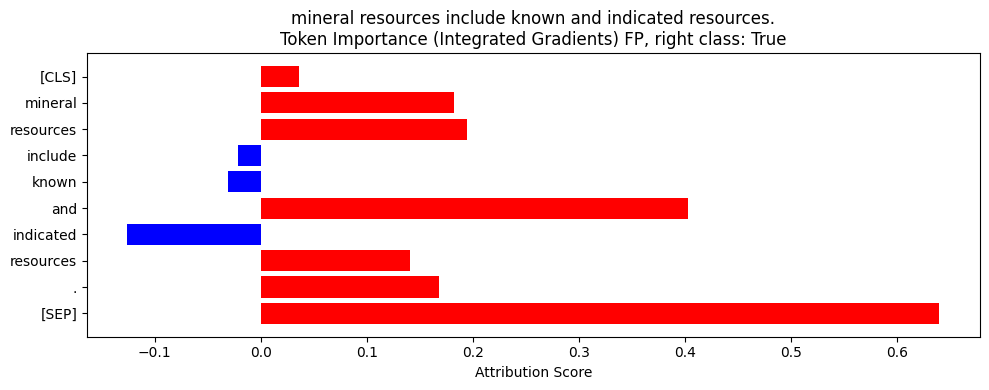

on august the eu commission granted marketing authorization for vyvgart efgartigimod alfafcab as an addon to standard therapy for the treatment of adult patients with gmg who are achrab in all eu member states iceland norway and liechtenstein collectively with the u.s. and japan the vyvgart approved countries .


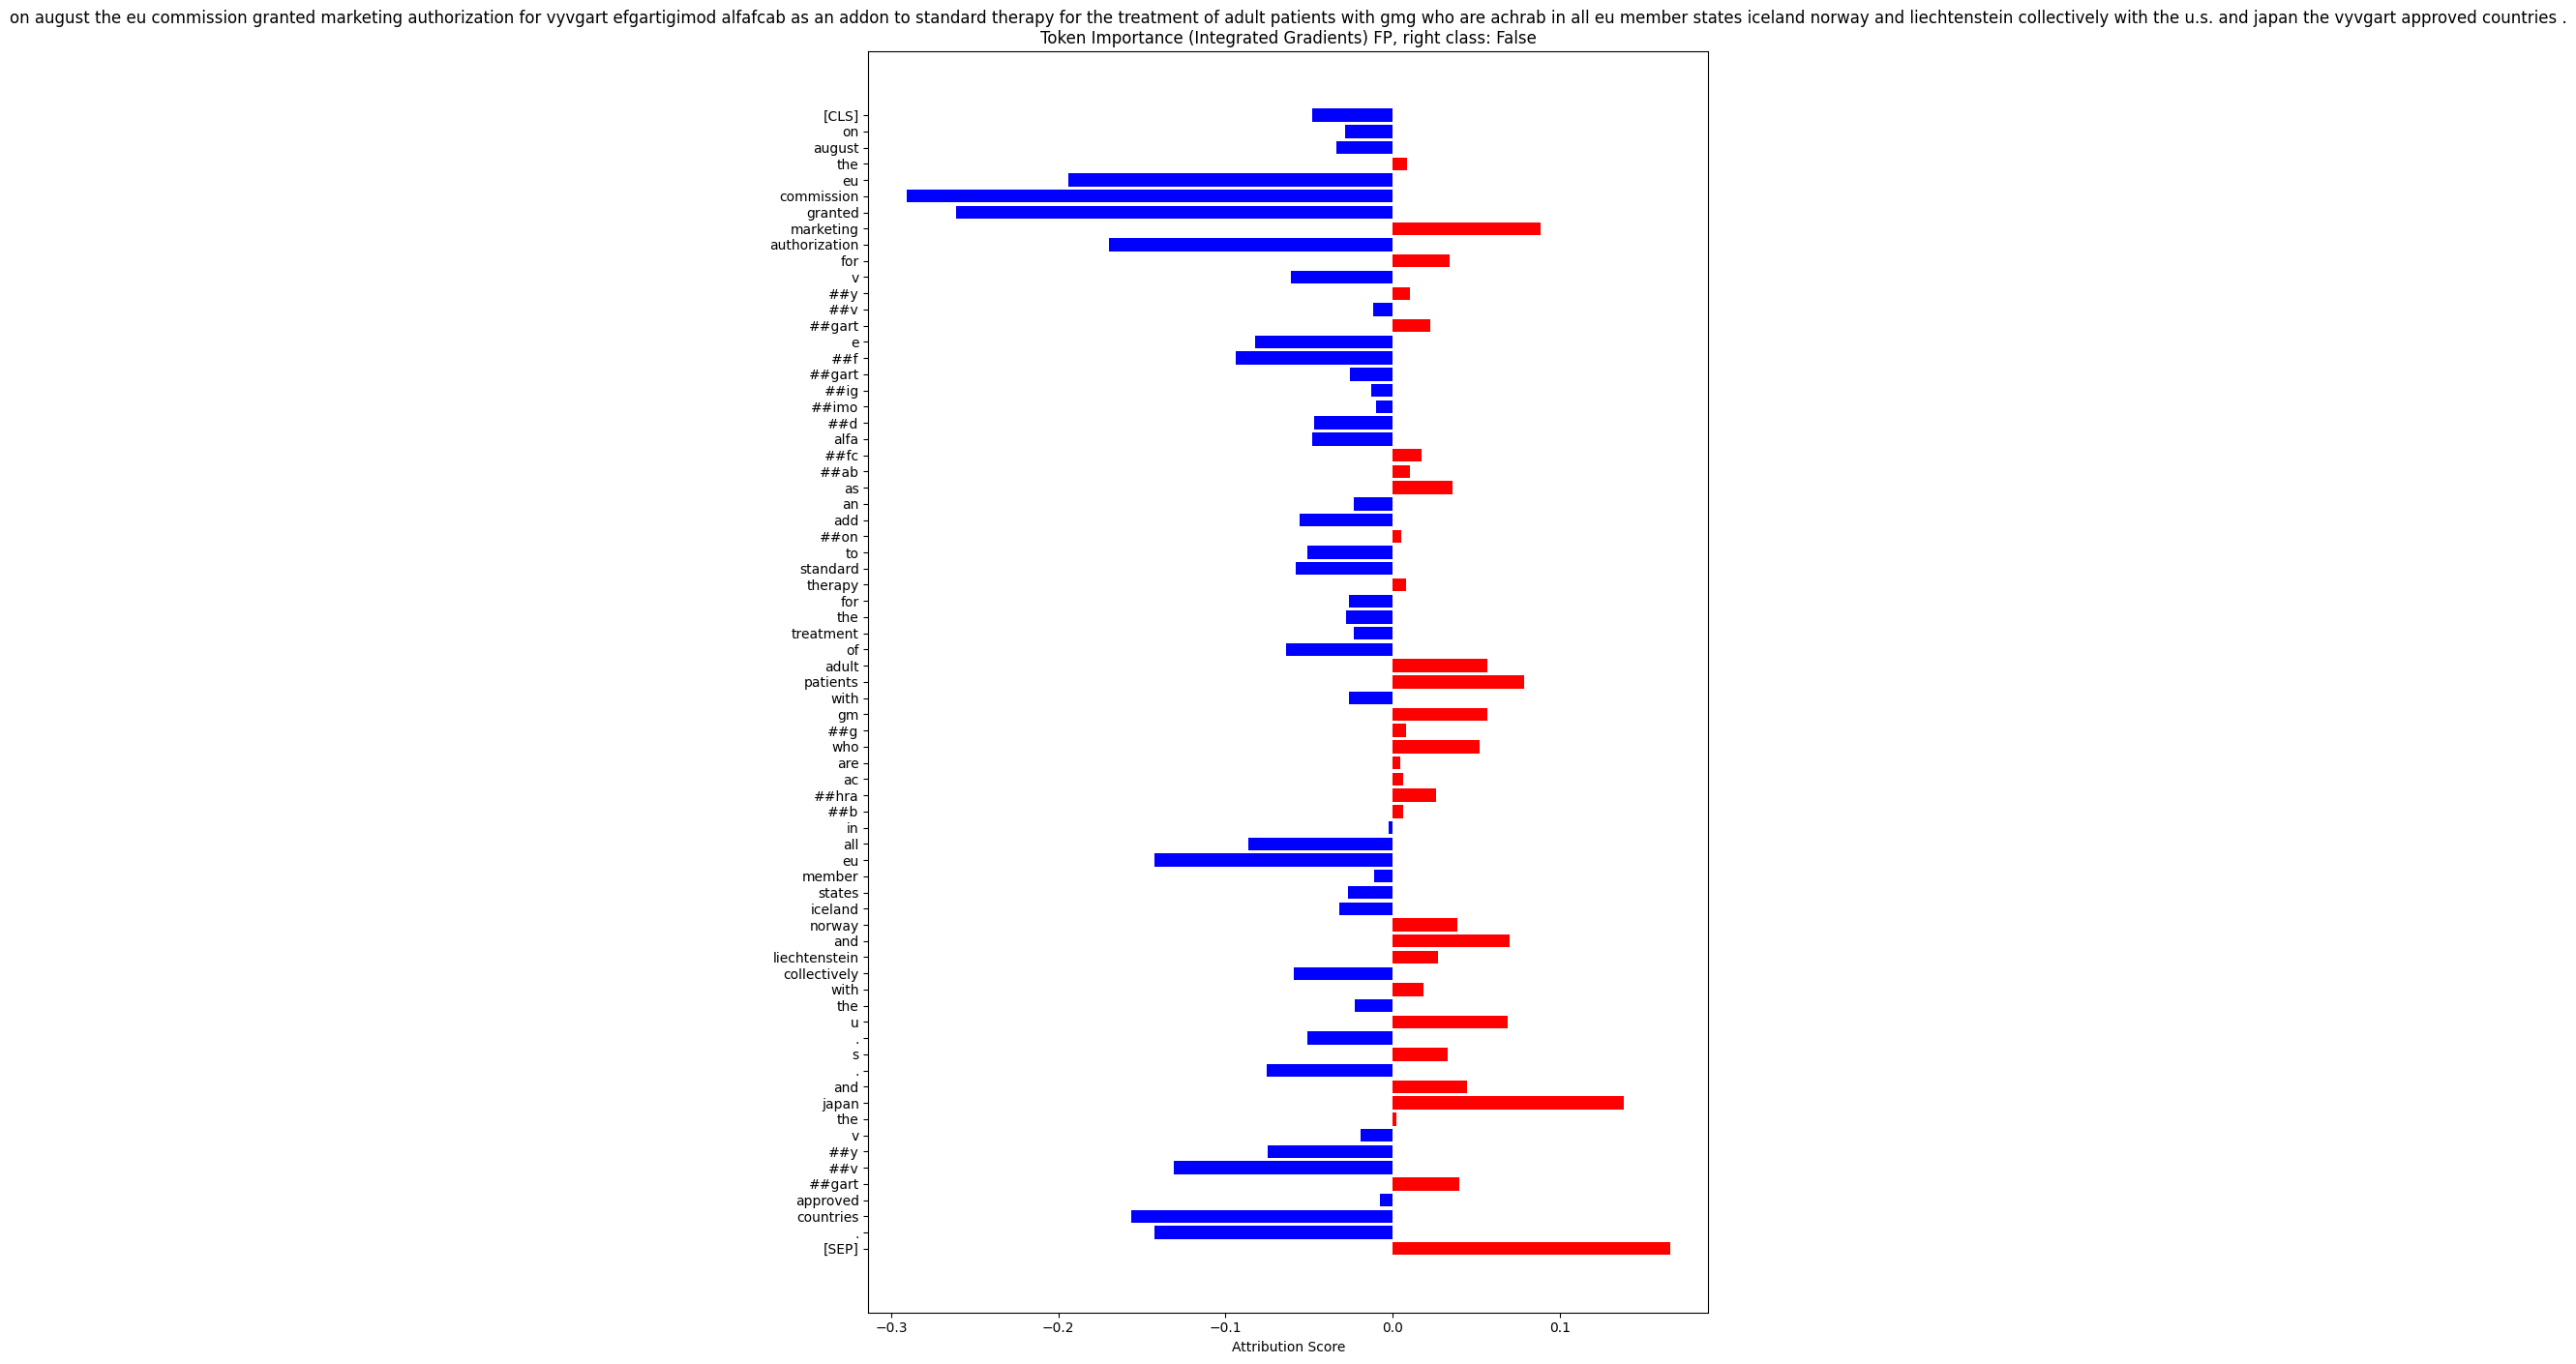

taking care of one of lifes essentials


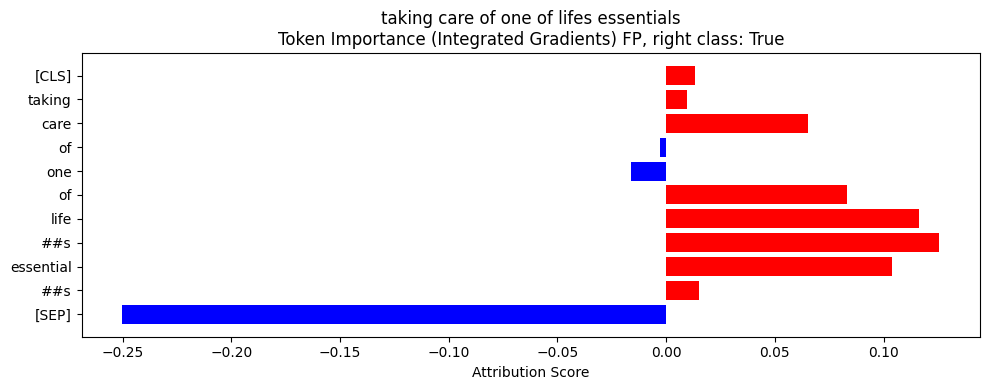

driven by the us trillion infrastructure investment amp jobs act infrastructure growth in the us will experience a significant boost in balfour beattys chosen states.


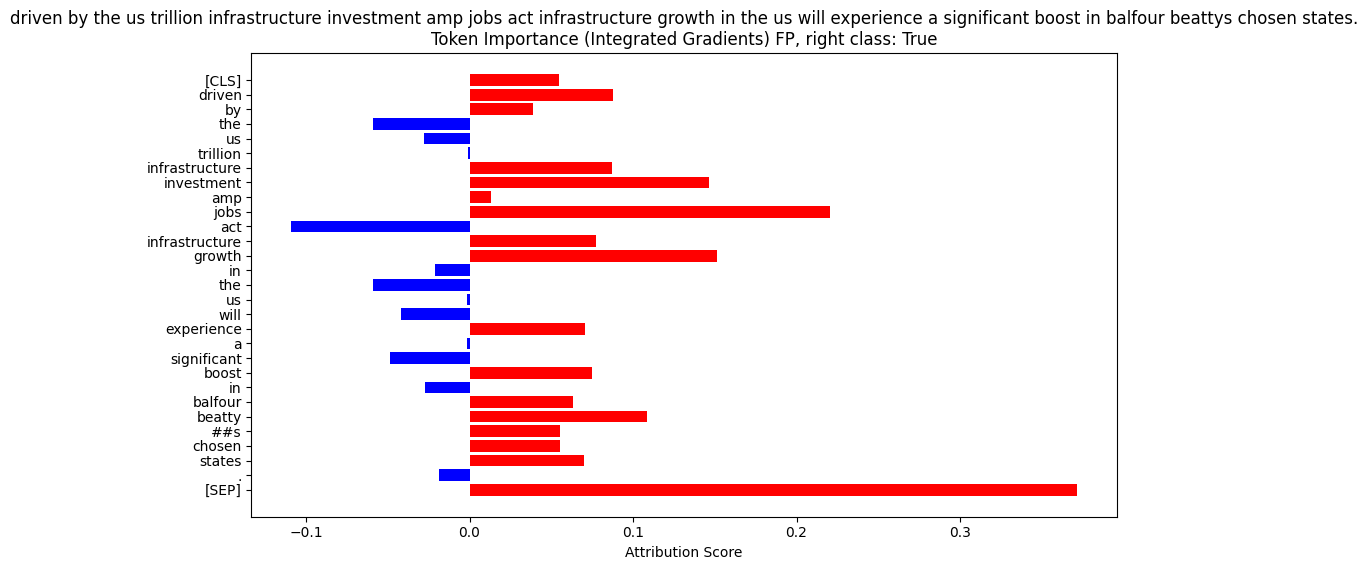

iii strategic land which is longerterm typically held under option.


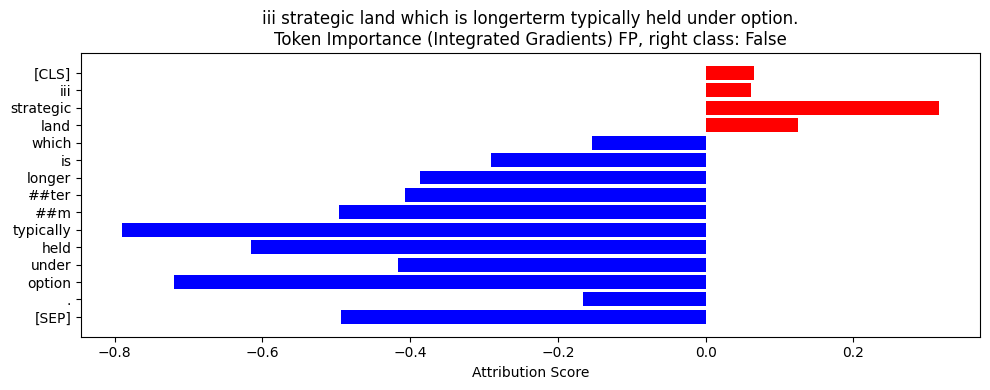

mieterplus exklusive anzeigen mit vorzeitiger kontaktaufnahme zusatzinformationen und chancenermittlung digitaler bewerbermappe für mietsuchende inklusive bonitätsauskunft


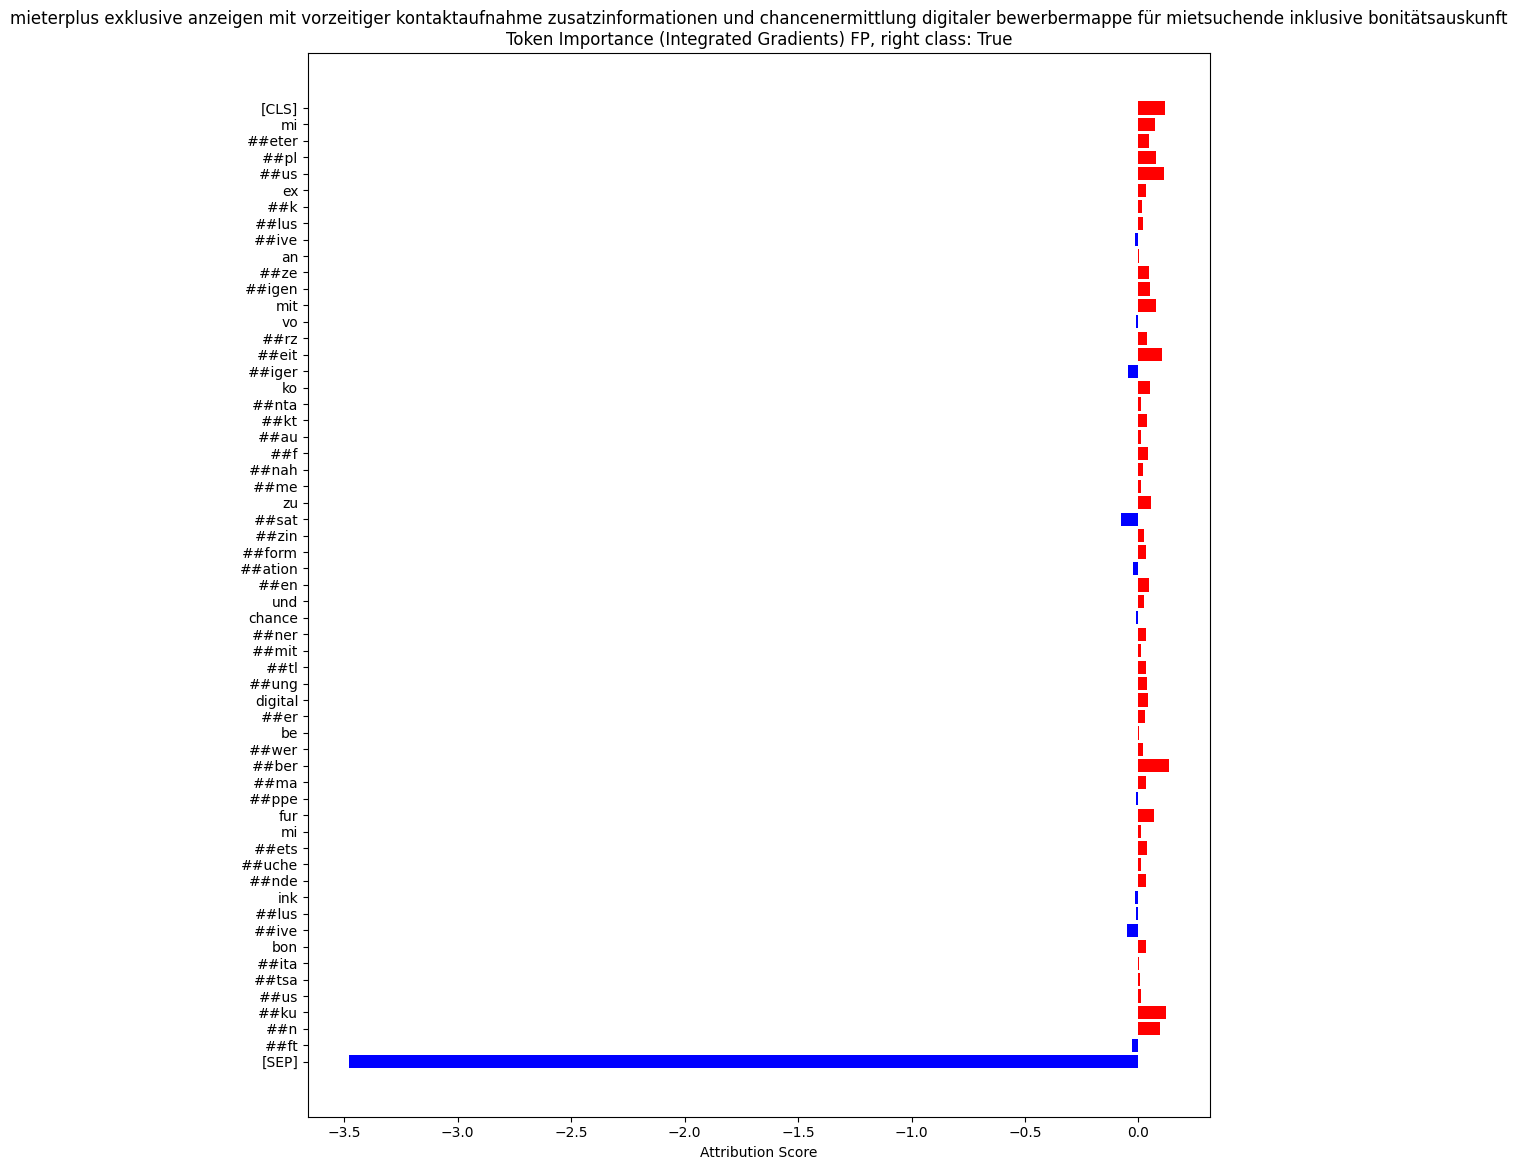

die erfüllung unserer verpflichtungen garantiert unseren aktionärinnen und aktionären ein langfristig attra


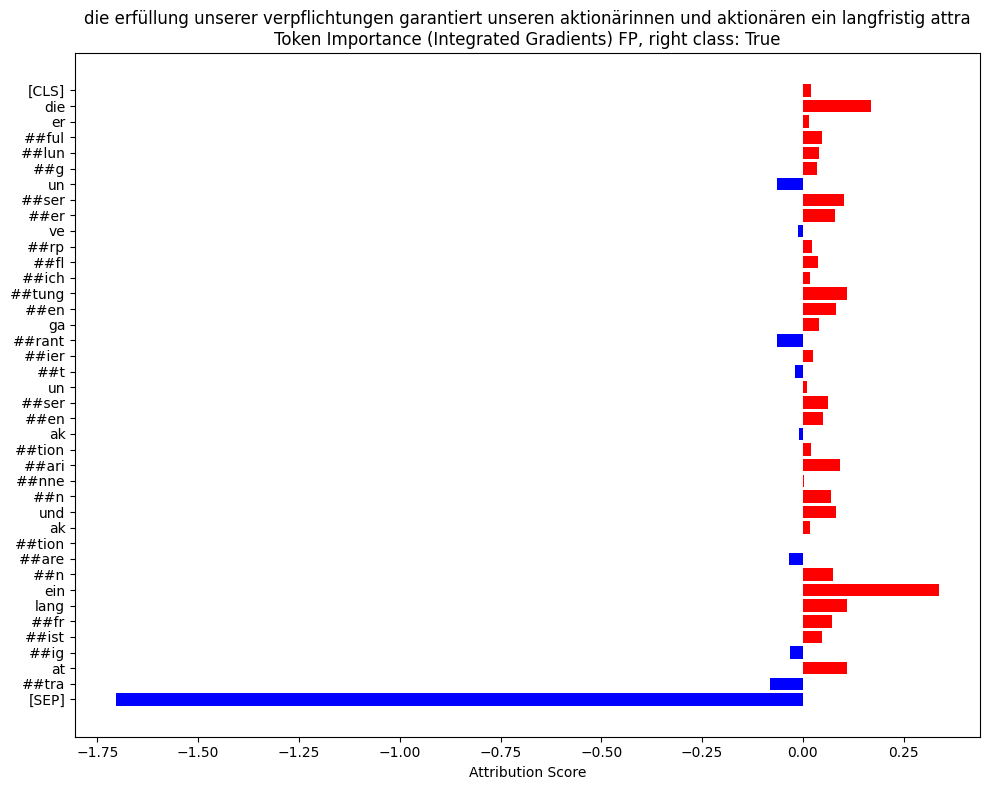

In [333]:
for sentence in df_test[(~df_test["positive"]) & (df_test["label"])].head(10)["text"]: 
    print(sentence)
    if len(sentence.split(" ")) > 4:
        classify_and_explain(sentence, model, tokenizer, "cpu", os.path.join(path_store, f"sentence_false_{i}"), "FP")